<img src="Logo_UNSAM.png" align="right" width="150" />

# Detector preictal de crisis epilépticas en CHB-MIT  
### Trabajo en desarrollo - Montserrat Coto

## Introducción

La epilepsia es un trastorno neurológico caracterizado por la aparición de crisis asociadas a una actividad eléctrica cerebral anormal y excesiva. Una de las herramientas más utilizadas para su estudio es el **electroencefalograma (EEG)**, que registra la actividad eléctrica del cerebro en función del tiempo. Dentro del análisis clásico del EEG suelen considerarse bandas de frecuencia estándar como **delta** (0.5–4 Hz), **theta** (4–8 Hz), **alpha** (8–13 Hz) y **beta** (13–30 Hz), ya que permiten describir distintos comportamientos de la señal.

Desde el punto de vista temporal, una crisis epiléptica puede dividirse en tres intervalos principales. El período **preictal** corresponde al tramo previo al inicio de la crisis; el período **ictal** es la crisis propiamente dicha; y el período **postictal** abarca la etapa posterior, donde la señal retorna gradualmente a un estado basal o presenta alteraciones residuales. En este trabajo el interés está puesto especialmente en el **período preictal**, ya que el objetivo es explorar si existe algún patrón que permita anticipar la crisis antes de su comienzo formal.

Como referencia conceptual se toma la idea general de la tesis original basada en el dataset **CHB-MIT**, orientada a la detección automática de crisis epilépticas a partir de registros reales de EEG. En lugar de reproducir exactamente toda su metodología, aquí se propone una **recreación con herramientas de la materia**, privilegiando un desarrollo más simple, gradual y entendible desde el punto de vista del procesamiento digital de señales.

Para eso se adopta un enfoque **paciente-específico**, trabajando inicialmente con **un solo paciente y un canal por vez**. A partir de los archivos EDF y del archivo summary del paciente, se construye un pipeline que incluye: lectura de registros, filtrado pasabanda, eliminación de baseline residual mediante un filtro no lineal de mediana, exploración visual de segmentos cercanos al inicio de crisis, construcción de una plantilla preictal y posterior aplicación de un **filtro adaptado** o *matched filter*. Finalmente, las detecciones obtenidas se comparan con las crisis anotadas en el summary.

La intención general del trabajo es vincular un problema real de procesamiento biomédico con conceptos vistos en la cursada, justificando cada decisión de diseño y evaluando, de manera exploratoria, si una metodología basada en plantillas preictales puede aportar información útil para una detección temprana.

# Desarrollo

### Imports y configuración general

En este primer bloque se cargan las librerías necesarias y se fijan los parámetros básicos del trabajo: la ruta del dataset, los archivos EDF a analizar, el canal seleccionado y las estructuras donde se van guardando los resultados.

El enfoque elegido es **paciente-específico**, de modo que el problema se reduce inicialmente a un conjunto acotado de registros y a un solo canal por vez. Esta decisión permite validar cada etapa del pipeline sin introducir de entrada la complejidad de un análisis multicanal o multipaciente.

Durante la exploración inicial se probaron distintos canales del paciente, comparando visualmente su comportamiento alrededor de las crisis. A partir de esa revisión, el canal **CZ-PZ** se tomó como canal principal de trabajo, ya que mostró una dinámica relativamente clara y una relación visual razonable entre actividad basal y cambios próximos a las crisis. Otros canales también resultaron interesantes, pero en varios casos aparecían patrones menos consistentes o señales más difíciles de interpretar de manera uniforme entre eventos.

In [23]:
# IMPORTS

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from pathlib import Path
import mne
import re
from pytc2.sistemas_lineales import plot_plantilla
from scipy.signal import find_peaks

plt.close("all")

# ARCHIVOS Y LECTURA DEL SUMMARY

# Rutas del dataset
ruta_base = Path(r"C:/Users/monse/OneDrive/Documentos/GitHub/Montserrat-Coto-APS/FINAL")
ruta_summary = ruta_base / "chb04-summary.txt"

# Archivos a procesar
lista_edf = [
    "chb04_01.edf",
    "chb04_05.edf",
    "chb04_08.edf",
    "chb04_28.edf",
]

# Canal elegido
# Ranking de mejores canales
canal_sel = "CZ-PZ"
#canal_sel = "P7-T7"
#canal_sel = "FT9-FT10"
#canal_sel = "T7-FT9"
#canal_sel = "F7-T7"
#canal_sel = "FP2-F8"

# Frecuencia de muestreo esperada
fs_esperada = 256.0

# Diccionarios / listas donde se guardan resultados
eeg_por_archivo = {}
segmentos_previos = []
crisis_filtradas = []
crisis_por_archivo = {}

### Lectura del *summary*

El archivo `summary` del paciente se usa como referencia temporal del trabajo, ya que indica en qué archivo aparece cada crisis y en qué segundo comienza y termina.

Esta información permite: identificar qué registros contienen crisis, recortar ventanas alrededor de cada evento, alinear segmentos respecto del inicio de crisis y finalmente evaluar si las detecciones obtenidas por el filtro adaptado ocurren en una zona compatible con el período preictal.

In [24]:

if not ruta_summary.exists():
    print("AVISO: no se encontró el summary")
else:
    patron_archivo = re.compile(r"^\s*File Name:\s*(.+?)\s*$", re.IGNORECASE)
    patron_ini = re.compile(r"^\s*Seizure(?:\s+\d+)?\s+Start\s+Time:\s*(\d+)\s*seconds", re.IGNORECASE)
    patron_fin = re.compile(r"^\s*Seizure(?:\s+\d+)?\s+End\s+Time:\s*(\d+)\s*seconds", re.IGNORECASE)

    nombre_actual = None
    inicio_actual = None

    lineas = ruta_summary.read_text(encoding="utf-8", errors="ignore").splitlines()

    for linea in lineas:
        s = linea.strip()

        m_archivo = patron_archivo.match(s)
        if m_archivo:
            nombre_actual = m_archivo.group(1).strip()
            crisis_por_archivo.setdefault(nombre_actual, [])
            inicio_actual = None
            continue

        if nombre_actual is None:
            continue

        m_ini = patron_ini.match(s)
        if m_ini:
            inicio_actual = int(m_ini.group(1))
            continue

        m_fin = patron_fin.match(s)
        if m_fin and inicio_actual is not None:
            fin_actual = int(m_fin.group(1))
            crisis_por_archivo[nombre_actual].append((inicio_actual, fin_actual))
            inicio_actual = None

print("CRISIS ENCONTRADAS EN EL SUMMARY")
for nombre_edf in lista_edf:
    print(nombre_edf, "->", crisis_por_archivo.get(nombre_edf, []))

CRISIS ENCONTRADAS EN EL SUMMARY
chb04_01.edf -> []
chb04_05.edf -> [(7804, 7853)]
chb04_08.edf -> [(6446, 6557)]
chb04_28.edf -> [(1679, 1781), (3782, 3898)]


### Diseño del filtro digital

Como etapa de preprocesamiento se utilizó un filtro pasabanda **IIR Butterworth**. La elección de esta aproximación se debe a que presenta una respuesta de amplitud suave en banda pasante, sin ondulaciones, lo que resulta conveniente cuando se busca preservar la morfología general de la señal dentro del rango útil.

Las especificaciones elegidas fueron:

- banda de paso: **0.5 a 25 Hz**
- banda de detención: por debajo de **0.2 Hz** y por encima de **30 Hz**
- rizado máximo en banda de paso: **0.5 dB**
- atenuación mínima en banda de detención: **40 dB**

Este criterio se apoyó en dos ideas. Por un lado, atenuar componentes de muy baja frecuencia asociadas a deriva lenta o baseline. Por otro, concentrar el análisis en un rango coherente con las bandas clásicas del EEG que resultan más relevantes en esta etapa, principalmente hasta beta.

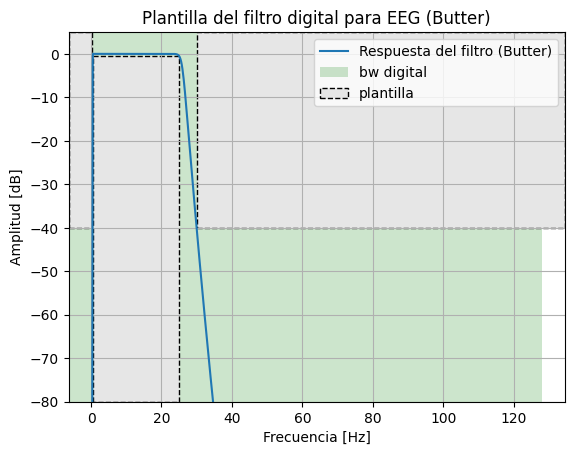

In [25]:

#DISEÑO DEL FILTRO

filter_type = 'bandpass'
aprox_name = 'butter'

fpass = np.array([0.5, 25.0])      # Banda de paso
fstop = np.array([0.2, 30.0])      # Banda de detención
ripple = 0.5                       # Rizado en banda de paso [dB]
attenuation = 40                   # Atenuación en banda de detención [dB]

mi_sos_butter = sig.iirdesign(
    wp=fpass,
    ws=fstop,
    gpass=ripple,
    gstop=attenuation,
    ftype=aprox_name,
    output='sos',
    fs=fs_esperada
)

# Visualización de plantilla y respuesta en frecuencia
nyq_frec = fs_esperada / 2.0

f_low = np.linspace(0.01, 0.4, 300)
f_fine = np.linspace(0.4, 0.6, 500)
f_high = np.linspace(0.6, nyq_frec, 700)
f_total = np.concatenate((f_low, f_fine, f_high))

w_rad = f_total / nyq_frec * np.pi
w, hh = sig.sosfreqz(mi_sos_butter, worN=w_rad)

plt.figure()
plt.plot(
    w / np.pi * nyq_frec,
    20 * np.log10(np.abs(hh) + 1e-15),
    label='Respuesta del filtro (Butter)'
)
plt.title('Plantilla del filtro digital para EEG (Butter)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.grid(True)
plt.ylim([-80, 5])

plot_plantilla(
    filter_type=filter_type,
    fpass=fpass,
    ripple=ripple,
    fstop=fstop,
    attenuation=attenuation,
    fs=fs_esperada
)

plt.show()

### Lectura de EDF y aplicación del filtro

En este paso se abre cada archivo EDF, se toma el canal seleccionado y se convierte la señal a **microvoltios**.

Después se aplica el filtro con `sosfiltfilt`, que se eligió porque hace un filtrado hacia adelante y hacia atrás, dejando una fase prácticamente nula. Esto es importante porque interesa preservar bien la posición temporal de los eventos.

In [26]:
#%% APLICACIÓN DEL FILTRO A LA SEÑAL

for nombre_edf in lista_edf:
    ruta_edf = ruta_base / nombre_edf

    if not ruta_edf.exists():
        continue

    try:
        raw = mne.io.read_raw_edf(str(ruta_edf), preload=True, verbose=False)
    except Exception:
        continue

    if canal_sel not in raw.ch_names:
        continue

    data, tiempos_s = raw.get_data(picks=[canal_sel], return_times=True)

    x_V = data[0]
    fs = float(raw.info["sfreq"])

    x_crudo = x_V * 1e6

    print("Canal leído", canal_sel)
    print("Cantidad de muestras:", len(x_crudo))
    print("fs detectada:", fs)

    x_filtrada = sig.sosfiltfilt(mi_sos_butter, x_crudo)

    eeg_por_archivo[nombre_edf] = {
        "x_crudo": x_crudo,
        "x_filtrada": x_filtrada,
        "t": tiempos_s,
        "fs": fs,
        "crisis": crisis_por_archivo.get(nombre_edf, [])
    }

C:\Users\monse\AppData\Local\Temp\ipykernel_19408\2997872832.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(ruta_edf), preload=True, verbose=False)


Canal leído CZ-PZ
Cantidad de muestras: 3685888
fs detectada: 256.0


C:\Users\monse\AppData\Local\Temp\ipykernel_19408\2997872832.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(ruta_edf), preload=True, verbose=False)


Canal leído CZ-PZ
Cantidad de muestras: 2441216
fs detectada: 256.0


C:\Users\monse\AppData\Local\Temp\ipykernel_19408\2997872832.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(ruta_edf), preload=True, verbose=False)


Canal leído CZ-PZ
Cantidad de muestras: 3686400
fs detectada: 256.0


C:\Users\monse\AppData\Local\Temp\ipykernel_19408\2997872832.py:10: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(ruta_edf), preload=True, verbose=False)


Canal leído CZ-PZ
Cantidad de muestras: 3692288
fs detectada: 256.0


Graficando archivo: chb04_01.edf


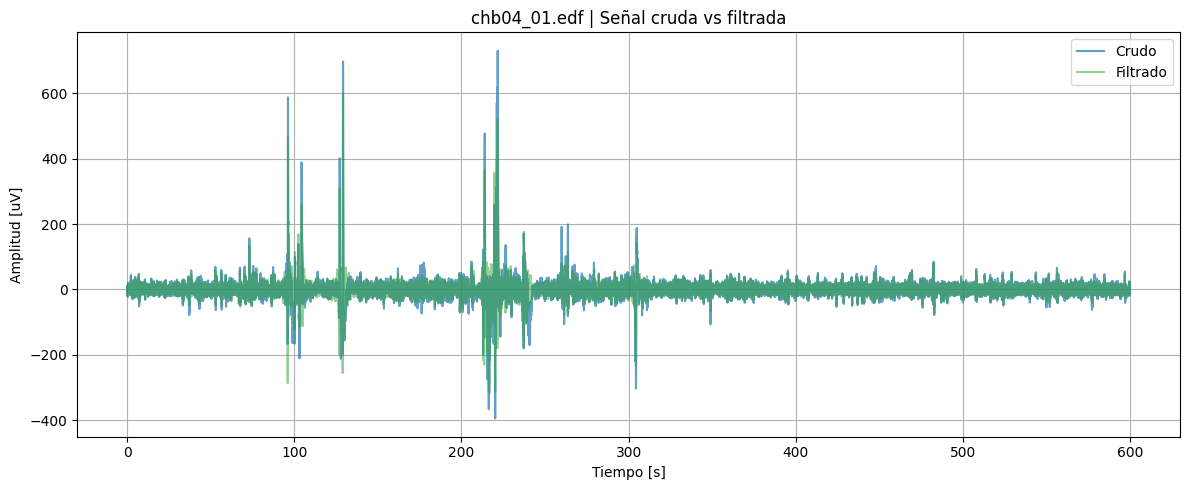

Graficando archivo: chb04_05.edf


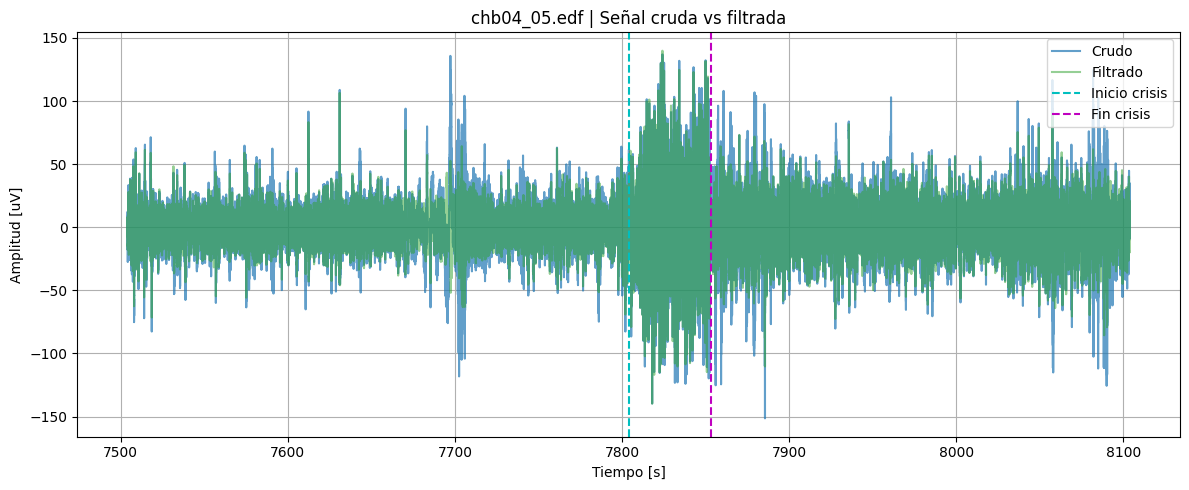

Graficando archivo: chb04_08.edf


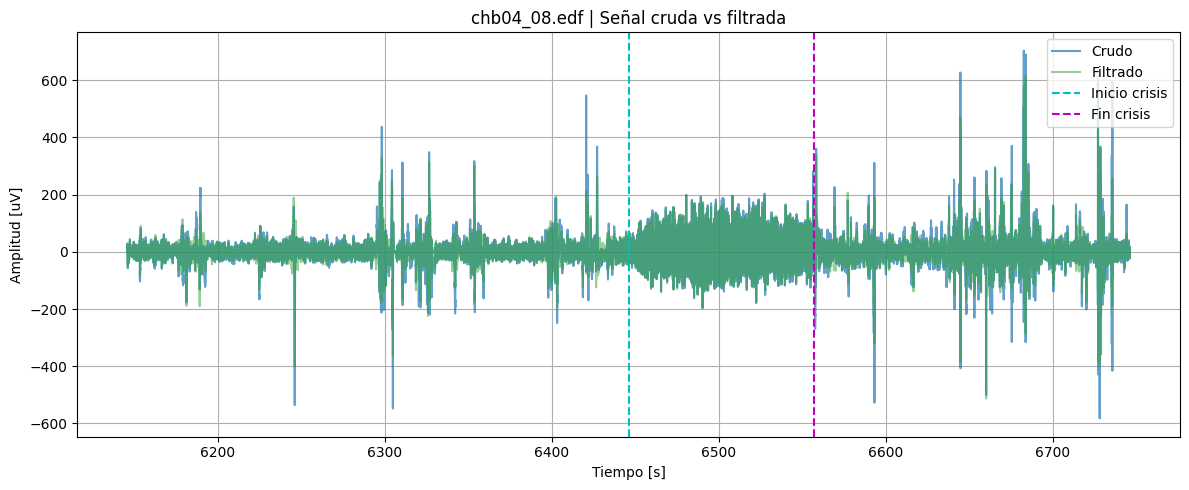

Graficando archivo: chb04_28.edf


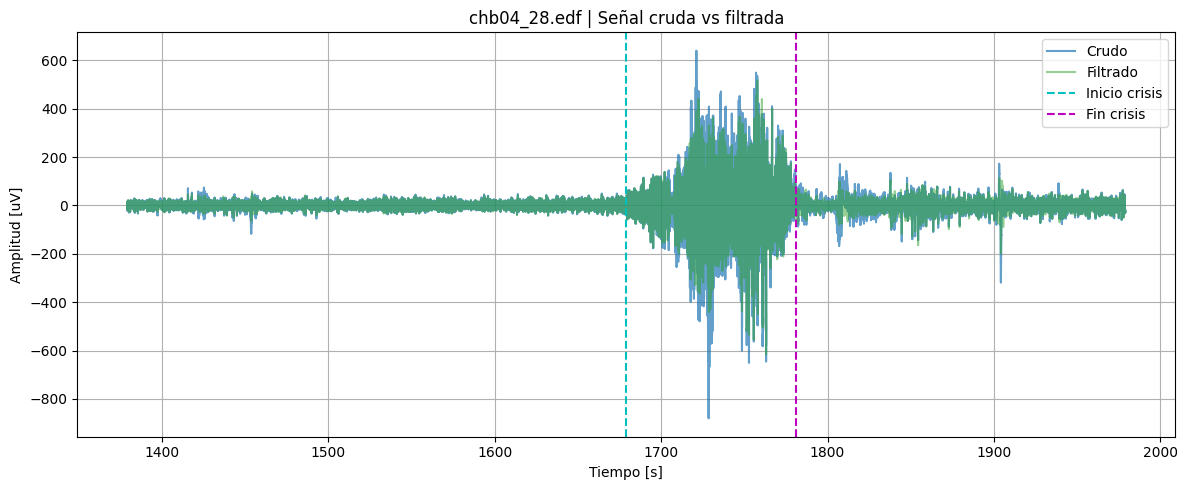

In [27]:
#%% GRAFICOS POR ARCHIVO - SEÑAL CRUDA VS FILTRADA

# Acá se grafica un tramo grande de cada archivo.
# Criterio elegido:
# - si el archivo tiene crisis, se toma una ventana de 5 minutos  alrededor de la primera crisis
# - si no tiene crisis, se grafican los primeros 5 minutos
# En todos los casos se marcan con líneas punteadas el inicio y fin de cada crisis que caiga dentro de la ventana graficada.

duracion_plot_s = 600.0   # 300 5 minutos; 180 3 min, 600 10min

# Lista para guardar los segmentos y después hacer un gráfico conjunto
segmentos_archivos = []

for nombre_edf in eeg_por_archivo:
    print("Graficando archivo:", nombre_edf)

    x_crudo = eeg_por_archivo[nombre_edf]["x_crudo"]
    x_filtrada = eeg_por_archivo[nombre_edf]["x_filtrada"]
    fs = eeg_por_archivo[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    # Si hay crisis, centrar la ventana en la primera
    if len(lista_crisis) > 0:
        ini_crisis_ref = lista_crisis[0][0]
        t_ini = ini_crisis_ref - duracion_plot_s / 2.0
        t_fin = ini_crisis_ref + duracion_plot_s / 2.0
    else:
        t_ini = 0.0
        t_fin = duracion_plot_s

    # Ajuste para no salir del archivo
    if t_ini < 0:
        t_ini = 0.0
        t_fin = duracion_plot_s

    tiempo_total_archivo = len(x_crudo) / fs

    if t_fin > tiempo_total_archivo:
        t_fin = tiempo_total_archivo
        t_ini = max(0.0, t_fin - duracion_plot_s)

    i0 = int(np.floor(t_ini * fs))
    i1 = int(np.ceil(t_fin * fs))

    if i0 < 0:
        i0 = 0
    if i1 > len(x_crudo):
        i1 = len(x_crudo)

    x_crudo_seg = x_crudo[i0:i1]
    x_filtrada_seg = x_filtrada[i0:i1]
    t_seg_abs = np.arange(i0, i1) / fs

    plt.figure(figsize=(12, 5))

    plt.plot(t_seg_abs, x_crudo_seg, color="tab:blue", label="Crudo", alpha=0.7)
    plt.plot(t_seg_abs, x_filtrada_seg, color="tab:green", label="Filtrado", alpha=0.5)

    # marcar crisis que caen dentro de la ventana
    for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        if t_ini <= ini_crisis <= t_fin or t_ini <= fin_crisis <= t_fin:
            if i == 0:
                plt.axvline(ini_crisis, color="c", linestyle="--", linewidth=1.5, label="Inicio crisis")
                plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")
            else:
                plt.axvline(ini_crisis, color="c", linestyle="--", linewidth=1.5)
                plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5)

    plt.title(nombre_edf + " | Señal cruda vs filtrada")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [uV]")
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # guardar segmento para el gráfico conjunto
    segmentos_archivos.append({
        "archivo": nombre_edf,
        "t_seg_abs": t_seg_abs,
        "x_crudo_seg": x_crudo_seg,
        "x_filtrada_seg": x_filtrada_seg,
        "crisis": lista_crisis,
        "t_ini": t_ini,
        "t_fin": t_fin
    })

### Filtro no lineal de mediana para quitar *baseline* residual

Después del filtrado pasabanda se observó que todavía podía permanecer cierto *baseline*. Para corregirlo se agregó una etapa de filtrado no lineal mediante **mediana**, aplicada sobre la señal ya filtrada.

La idea es obtenerla para estimar una tendencia lenta de la señal y luego esa estimación se resta, obteniendo una versión más limpia. A partir de este punto, las etapas posteriores del trabajo se apoyan principalmente en la señal **filtrada y sin baseline**, ya que es la versión que ofrece una lectura más clara para la exploración visual y para el filtro adaptado.

In [28]:
kernel_mediana = 257   # 257 muestras ~ 1 segundo, valor impar

for nombre_edf in eeg_por_archivo:
    x_filtrada = eeg_por_archivo[nombre_edf]["x_filtrada"]

    baseline_mediana = sig.medfilt(x_filtrada, kernel_mediana)
    x_filtrada_sin_baseline = x_filtrada - baseline_mediana

    eeg_por_archivo[nombre_edf]["baseline_mediana"] = baseline_mediana
    eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"] = x_filtrada_sin_baseline

    print("Mediana aplicada a:", nombre_edf)

Mediana aplicada a: chb04_01.edf
Mediana aplicada a: chb04_05.edf
Mediana aplicada a: chb04_08.edf
Mediana aplicada a: chb04_28.edf


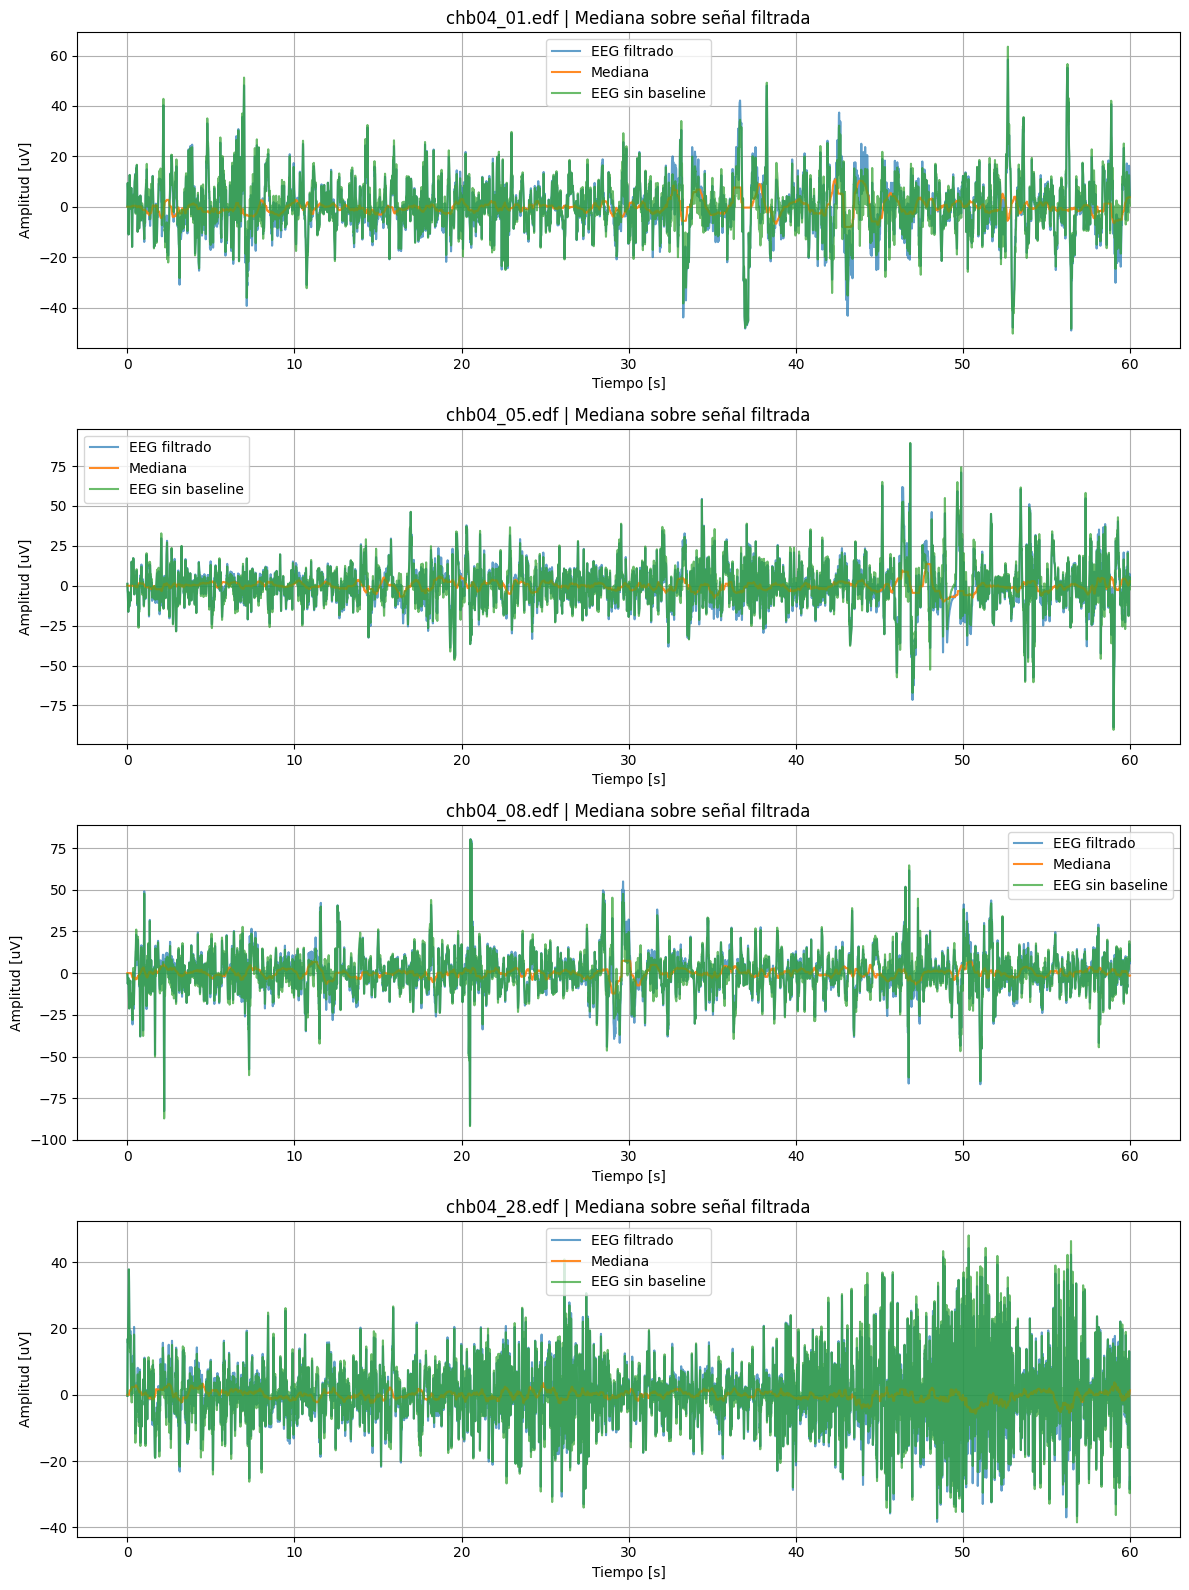

In [29]:
# GRAFICO CONJUNTO - MEDIANA EN TODOS LOS ARCHIVOS

if len(eeg_por_archivo) > 0:
    n_archivos = len(eeg_por_archivo)

    plt.figure(figsize=(12, 4 * n_archivos))

    k = 1

    for nombre_edf in eeg_por_archivo:
        x_filtrada = eeg_por_archivo[nombre_edf]["x_filtrada"]
        baseline_mediana = eeg_por_archivo[nombre_edf]["baseline_mediana"]
        x_filtrada_sin_baseline = eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"]
        t = eeg_por_archivo[nombre_edf]["t"]
        fs = eeg_por_archivo[nombre_edf]["fs"]

        # mismo tramo para todos: primeros 60 s
        t_ini = 0.0
        t_fin = 60.0

        i0 = int(np.floor(t_ini * fs))
        i1 = int(np.ceil(t_fin * fs))

        if i0 < 0:
            i0 = 0
        if i1 > len(t):
            i1 = len(t)

        plt.subplot(n_archivos, 1, k)

        plt.plot(t[i0:i1], x_filtrada[i0:i1], label='EEG filtrado', alpha=0.7)
        plt.plot(t[i0:i1], baseline_mediana[i0:i1], label='Mediana', alpha=0.9)
        plt.plot(t[i0:i1], x_filtrada_sin_baseline[i0:i1], label='EEG sin baseline', alpha=0.7)

        plt.title(nombre_edf + " | Mediana sobre señal filtrada")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud [uV]")
        plt.grid(True)
        plt.legend()

        k = k + 1

    plt.tight_layout()
    plt.show()
else:
    print("No hay archivos para graficar.")

### Visualización de crisis y exploración visual



Para cada crisis se construye una ventana temporal compuesta por tres tramos: **previo**, **ictal** y **posterior**.  
El criterio elegido fue tomar una ventana simétrica basada en la duración propia de cada crisis. Es decir, si una crisis dura:

`Tc = t_fin - t_ini`

entonces se define:

- **previo**: desde `t_ini - Tc` hasta `t_ini`
- **ictal**: desde `t_ini` hasta `t_fin`
- **posterior**: desde `t_fin` hasta `t_fin + Tc`

La idea de usar este criterio es que cada crisis quede observada en una escala proporcional a su propia duración, sin imponer una ventana fija que podría resultar demasiado corta en algunos casos o excesiva en otros. Además, al usar la misma duración antes y después del evento, la comparación visual queda más equilibrada y permite mirar con claridad qué cambia antes, durante y después de la crisis.

En cada caso se grafican dos subplots la **señal filtrada y sin baseline**

Este esquema permite comparar directamente cuánto mejora la interpretación visual luego del preprocesamiento. La señal ya tratada permite resaltar mejor las oscilaciones de interés y reducir la influencia de deriva lenta o componentes no deseadas.

El objetivo principal de esta etapa no es todavía detectar automáticamente, sino **explorar visualmente** si en el tramo previo al inicio aparecen formas o comportamientos que se repitan entre crisis. Esa exploración es la base para decidir después cómo construir una plantilla candidata para el filtro adaptado.

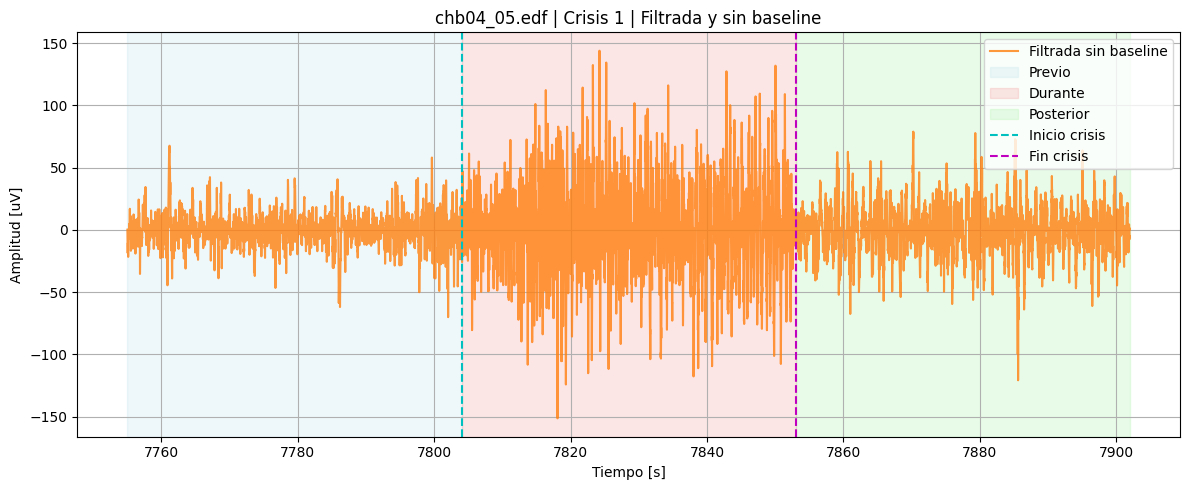

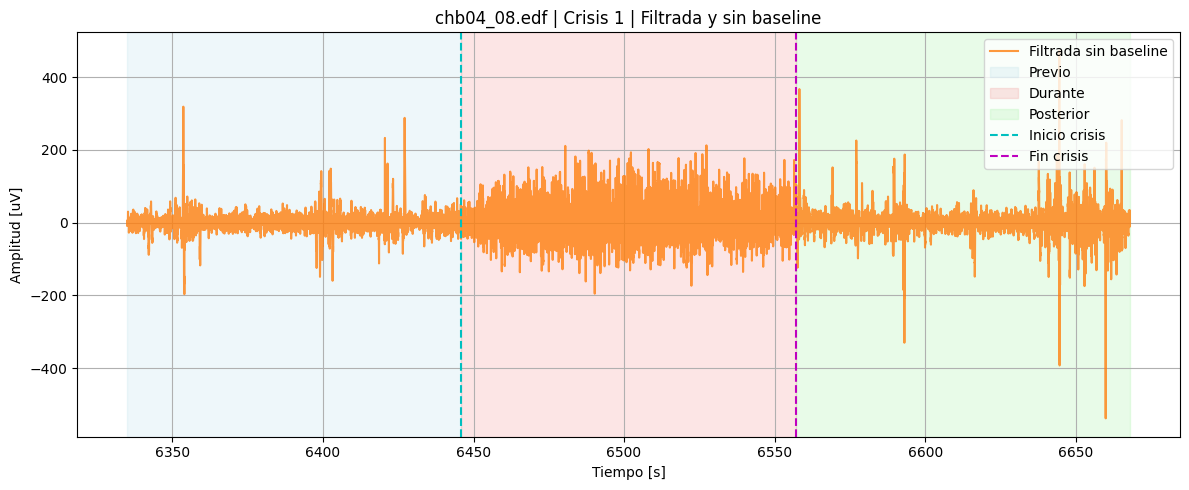

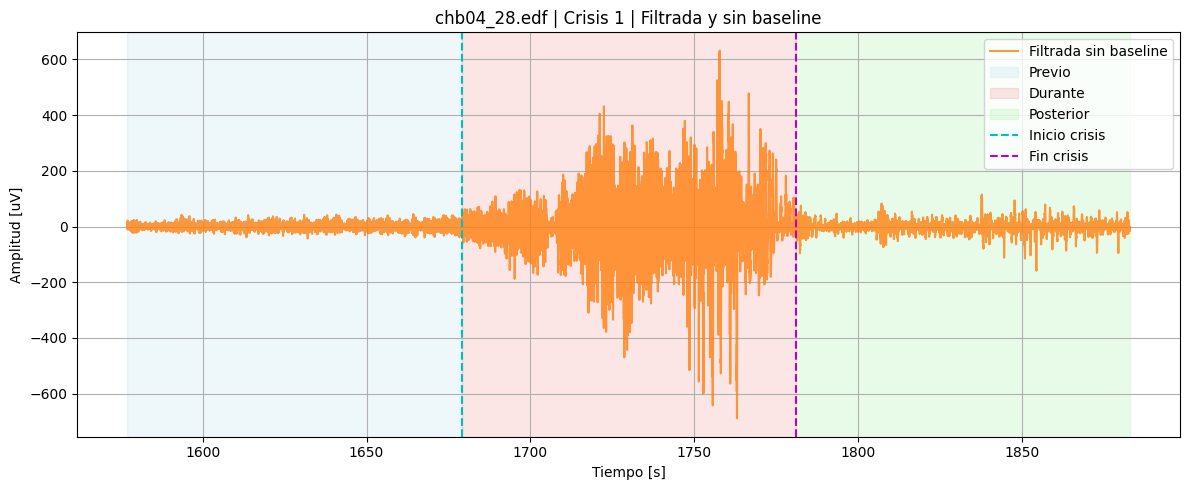

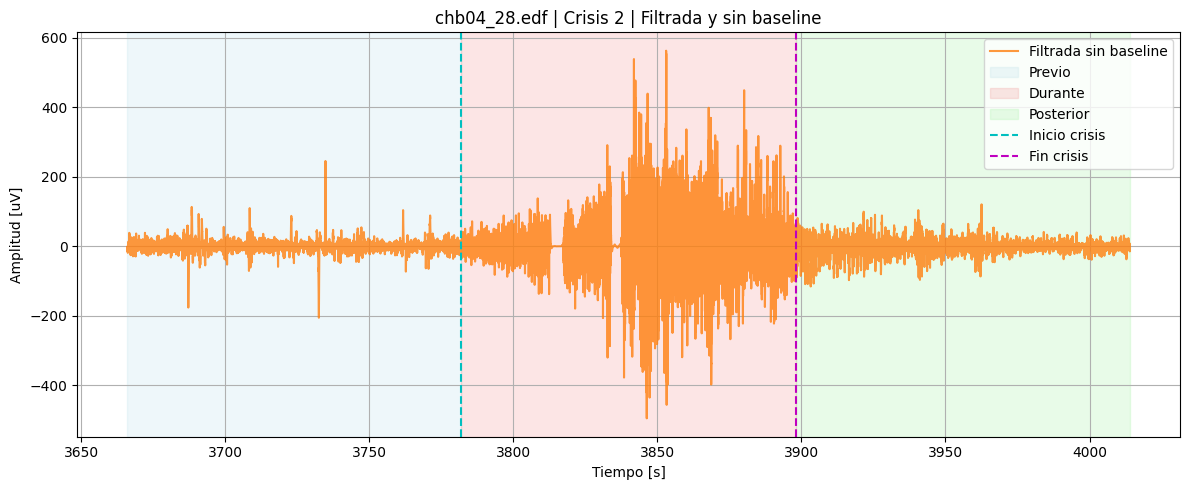

In [30]:
# GRAFICOS DE CADA CRISIS - SOLO SEÑAL FILTRADA Y SIN BASELINE

crisis_filtradas = []

for nombre_edf in eeg_por_archivo:
    x_limpia = eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"]
    fs = eeg_por_archivo[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    if len(lista_crisis) == 0:
        continue

    for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        Tc = fin_crisis - ini_crisis

        t_ini_total = ini_crisis - Tc
        t_fin_total = fin_crisis + Tc

        if t_ini_total < 0:
            t_ini_total = 0.0

        i0 = int(np.floor(t_ini_total * fs))
        i1 = int(np.ceil(t_fin_total * fs))

        if i0 < 0:
            i0 = 0
        if i1 > len(x_limpia):
            i1 = len(x_limpia)

        x_limpia_seg = x_limpia[i0:i1]
        t_seg_abs = np.arange(i0, i1) / fs

        t_prev_ini = max(0.0, ini_crisis - Tc)
        t_prev_fin = ini_crisis
        t_dur_ini = ini_crisis
        t_dur_fin = fin_crisis
        t_post_ini = fin_crisis
        t_post_fin = fin_crisis + Tc

        plt.figure(figsize=(12, 5))

        plt.plot(t_seg_abs, x_limpia_seg, color="tab:orange", label="Filtrada sin baseline", alpha=0.8)

        plt.axvspan(t_prev_ini, t_prev_fin, color="lightblue", alpha=0.2, label="Previo")
        plt.axvspan(t_dur_ini, t_dur_fin, color="lightcoral", alpha=0.2, label="Durante")
        plt.axvspan(t_post_ini, t_post_fin, color="lightgreen", alpha=0.2, label="Posterior")

        plt.axvline(ini_crisis, color="c", linestyle="--", linewidth=1.5, label="Inicio crisis")
        plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")

        plt.title(nombre_edf + " | Crisis " + str(i + 1) + " | Filtrada y sin baseline")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud [uV]")
        plt.grid(True)
        plt.legend(loc="upper right")

        plt.tight_layout()
        plt.show()

        crisis_filtradas.append({
            "archivo": nombre_edf,
            "crisis_num": i + 1,
            "t_seg_abs": t_seg_abs,
            "x_limpia_seg": x_limpia_seg,
            "ini_crisis": ini_crisis,
            "fin_crisis": fin_crisis,
            "Tc": Tc
        })

### Exploración del patrón candidato y armado de plantilla

Una vez obtenidas las señales más limpias, el análisis se concentra en el período **preictal**, ya que el objetivo no es reconocer una crisis ya establecida sino explorar si existe algún comportamiento previo que la anticipe.

Para eso se construyen ventanas alineadas respecto del inicio de crisis y luego se recorta una ventana fija previa al *onset*. A partir de esa base se consideran tres alternativas de plantilla:

1. **plantilla promedio**, obtenida a partir del promedio de varios segmentos preictales;
2. **plantilla manual**, tomada de una crisis considerada visualmente representativa;
3. **plantilla idealizada**, construida con una forma simple inspirada en una morfología tipo punta-onda.

La comparación entre estas tres opciones permite evaluar si conviene usar un patrón directamente extraído de los datos o una forma sintética más controlada.

#### OPCION 1 - PLANTILLA PROMEDIO DE SEGMENTOS PREICTALES ALINEADOS

In [31]:

#%% ETAPA 1 - EXPLORACION DEL PATRON CANDIDATO

t_antes = 5.0
t_despues = 5.0

segmentos_onset = []

for nombre_edf in eeg_por_archivo:
    x_limpia = eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"]
    fs = eeg_por_archivo[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    if len(lista_crisis) == 0:
        continue

    for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        t_ini = ini_crisis - t_antes
        t_fin = ini_crisis + t_despues

        if t_ini < 0:
            t_ini = 0.0

        i0 = int(np.floor(t_ini * fs))
        i1 = int(np.ceil(t_fin * fs))

        if i0 < 0:
            i0 = 0
        if i1 > len(x_limpia):
            i1 = len(x_limpia)

        x_seg = x_limpia[i0:i1]
        t_rel = np.arange(len(x_seg)) / fs - t_antes

        segmentos_onset.append({
            "archivo": nombre_edf,
            "crisis_num": i + 1,
            "fs": fs,
            "x_seg": x_seg,
            "t_rel": t_rel,
            "ini_crisis": ini_crisis,
            "fin_crisis": fin_crisis
        })

print("Cantidad de segmentos de onset guardados:", len(segmentos_onset))



Cantidad de segmentos de onset guardados: 4


In [32]:
#%% ETAPA 1.2 - DEFINIR VENTANA FIJA PREICTAL PARA LA PLANTILLA

t_pat_ini = -2.0
t_pat_fin = 0.0

segmentos_patron = []

for k in range(len(segmentos_onset)):
    t_rel = segmentos_onset[k]["t_rel"]
    x_seg = segmentos_onset[k]["x_seg"]

    mask = (t_rel >= t_pat_ini) & (t_rel <= t_pat_fin)

    t_pat = t_rel[mask]
    x_pat = x_seg[mask]

    segmentos_patron.append({
        "archivo": segmentos_onset[k]["archivo"],
        "crisis_num": segmentos_onset[k]["crisis_num"],
        "t_pat": t_pat,
        "x_pat": x_pat
    })

print("Cantidad de segmentos candidatos para plantilla:", len(segmentos_patron))



Cantidad de segmentos candidatos para plantilla: 4


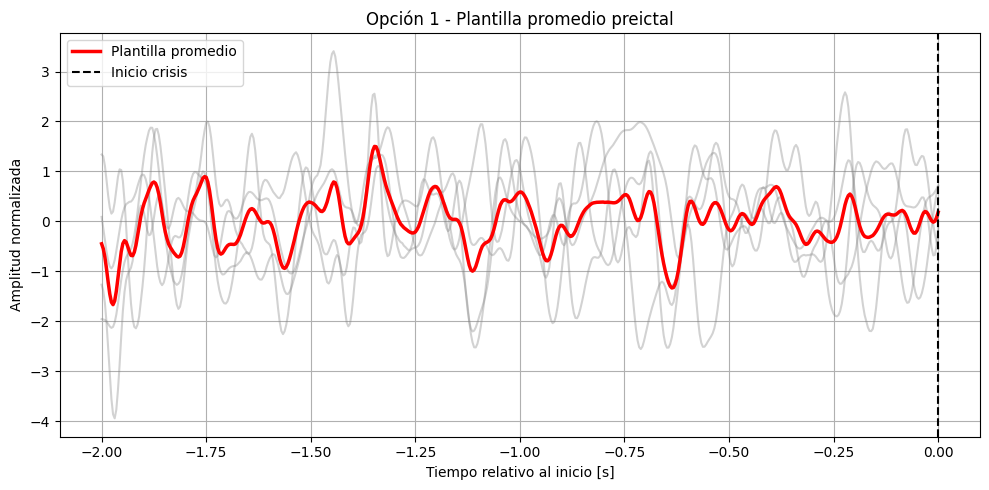

In [33]:
#%% OPCION 1 - PLANTILLA PROMEDIO DE SEGMENTOS PREICTALES ALINEADOS

largos = []

for k in range(len(segmentos_patron)):
    largos.append(len(segmentos_patron[k]["x_pat"]))

largo_min = min(largos)

matriz_pat = []

for k in range(len(segmentos_patron)):
    x_pat = segmentos_patron[k]["x_pat"][:largo_min]
    x_pat = x_pat - np.mean(x_pat)
    x_pat = x_pat / (np.std(x_pat) + 1e-12)
    matriz_pat.append(x_pat)

matriz_pat = np.array(matriz_pat)

plantilla = np.mean(matriz_pat, axis=0)
t_plantilla = segmentos_patron[0]["t_pat"][:largo_min]

plt.figure(figsize=(10, 5))

for k in range(matriz_pat.shape[0]):
    plt.plot(t_plantilla, matriz_pat[k, :], color="gray", alpha=0.35)

plt.plot(t_plantilla, plantilla, color="red", linewidth=2.5, label="Plantilla promedio")
plt.axvline(0, color="k", linestyle="--", linewidth=1.5, label="Inicio crisis")
plt.title("Opción 1 - Plantilla promedio preictal")
plt.xlabel("Tiempo relativo al inicio [s]")
plt.ylabel("Amplitud normalizada")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Opción 1 – Filtro adaptado y detección de picos

Con la plantilla promedio se aplica un **filtro adaptado** o *matched filter*. La lógica consiste en correlacionar la señal con la plantilla invertida en el tiempo, de modo de resaltar aquellos tramos donde ambas tengan una forma similar.

La salida del filtro no se interpreta directamente como una detección, por lo que luego se busca sus máximos usando un criterio simple:

- un umbral definido como porcentaje del máximo de la salida,
- y una distancia mínima entre picos para evitar múltiples detecciones muy cercanas.

Esta primera prueba sirve principalmente para evaluar si el promedio preictal logra conservar una forma suficientemente representativa.

El filtro adaptado se aplica sobre la señal **filtrada y sin baseline**, de modo que la comparación con la plantilla se haga sobre una señal lo más limpia posible. Después se observan los máximos de la salida alrededor de cada crisis para ver si aparecen respuestas destacadas en el intervalo preictal.

Filtro adaptado aplicado a: chb04_01.edf
Filtro adaptado aplicado a: chb04_05.edf
Filtro adaptado aplicado a: chb04_08.edf
Filtro adaptado aplicado a: chb04_28.edf
chb04_01.edf -> cantidad de picos detectados: 6
chb04_05.edf -> cantidad de picos detectados: 14
chb04_08.edf -> cantidad de picos detectados: 19
chb04_28.edf -> cantidad de picos detectados: 26


C:\Users\monse\AppData\Local\Temp\ipykernel_19408\820887063.py:77: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


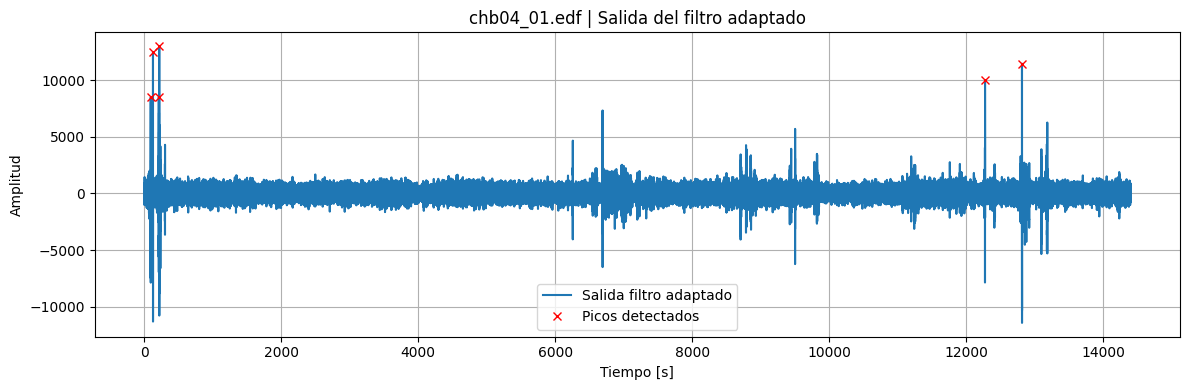

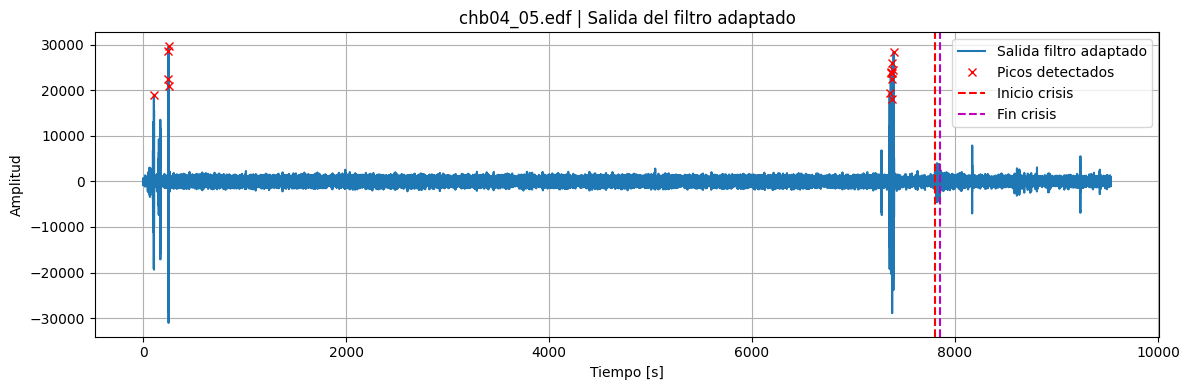

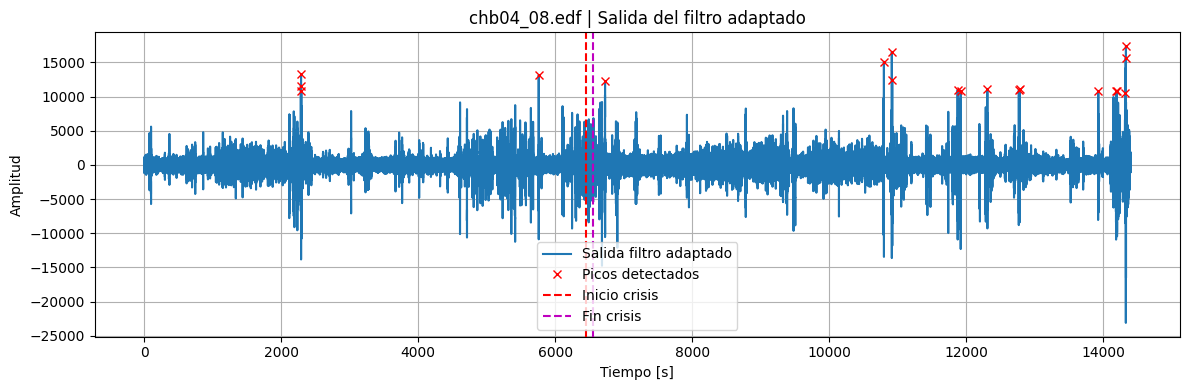

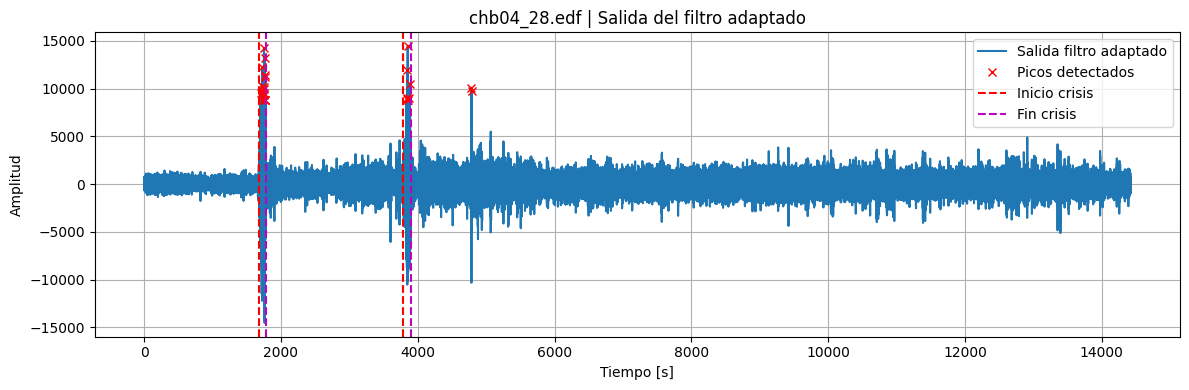

In [34]:
resultados_filtro = {}

for nombre_edf in eeg_por_archivo:
    x_limpia = eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"]
    fs = eeg_por_archivo[nombre_edf]["fs"]

    # centrar la señal para sacar el nivel medio
    senal_centrada = x_limpia - np.mean(x_limpia)

    # invertir la plantilla en el tiempo y centrarla
    plantilla_centrada = plantilla[::-1] - np.mean(plantilla)

    # filtro adaptado por convolución
    salida_filtro = np.convolve(senal_centrada, plantilla_centrada, mode='same')

    resultados_filtro[nombre_edf] = {
        "salida_filtro": salida_filtro,
        "fs": fs
    }

    print("Filtro adaptado aplicado a:", nombre_edf)

for nombre_edf in resultados_filtro:
    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    fs = resultados_filtro[nombre_edf]["fs"]

    # solo voy a aceptar como picos aquellos máximos que superen
    # el 60% del máximo valor de toda la salida del filtro
    height_threshold = np.max(salida_filtro) * 0.6

    # distancia mínima entre picos
    # se toma 1 segundo para no detectar muchos máximos muy juntos
    distance_threshold = int(fs * 1.0)

    peaks, _ = find_peaks(
        salida_filtro,
        height=height_threshold,
        distance=distance_threshold
    )

    resultados_filtro[nombre_edf]["peaks"] = peaks
    resultados_filtro[nombre_edf]["height_threshold"] = height_threshold

    print(nombre_edf, "-> cantidad de picos detectados:", len(peaks))


#%% GRAFICOS DEL FILTRO ADAPTADO
# Este gráfico muestra solo la salida del filtro adaptado,
# junto con los picos detectados y el inicio/fin real de cada crisis.

for nombre_edf in resultados_filtro:
    t = eeg_por_archivo[nombre_edf]["t"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    peaks = resultados_filtro[nombre_edf]["peaks"]

    plt.figure(figsize=(12, 4))

    plt.plot(t, salida_filtro, color="tab:blue", label="Salida filtro adaptado")
    plt.plot(t[peaks], salida_filtro[peaks], "rx", label="Picos detectados")

    for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        if i == 0:
            plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
            plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")
        else:
            plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5)
            plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5)

    plt.title(nombre_edf + " | Salida del filtro adaptado")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

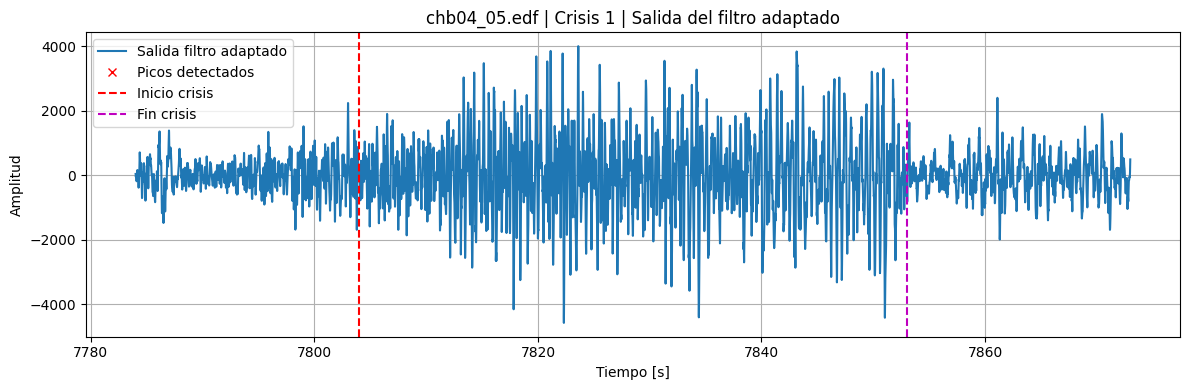

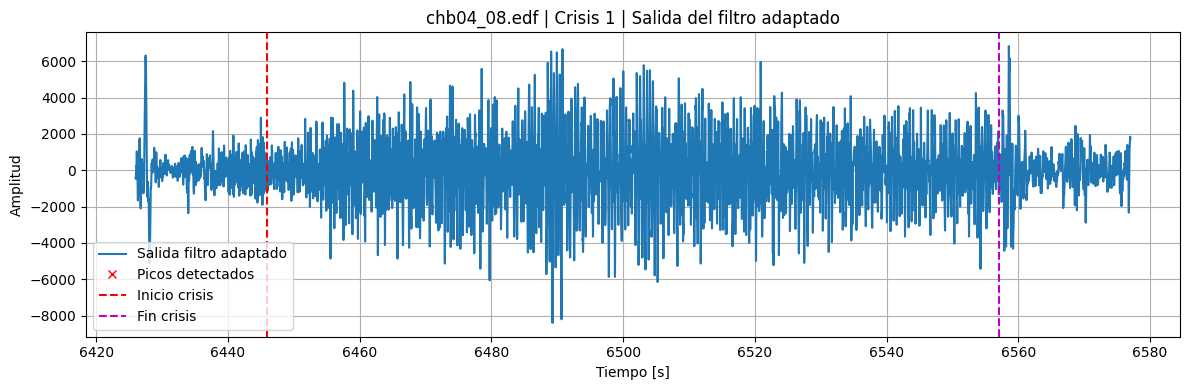

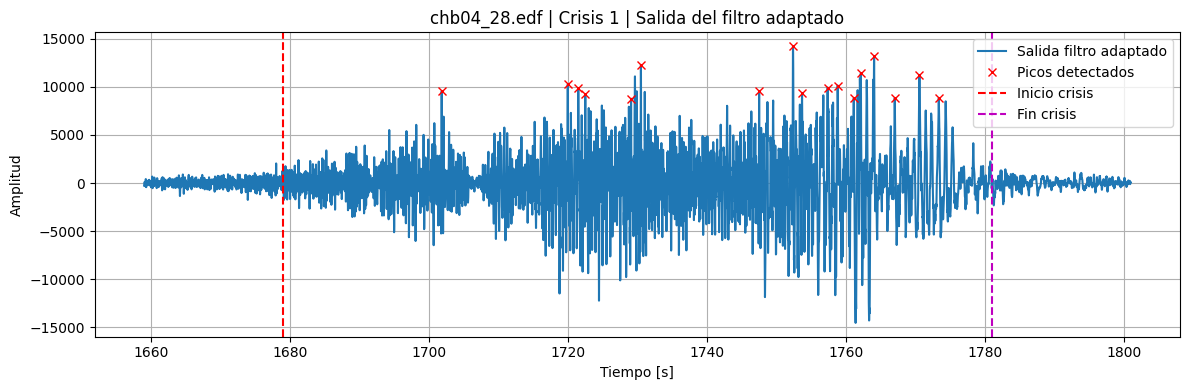

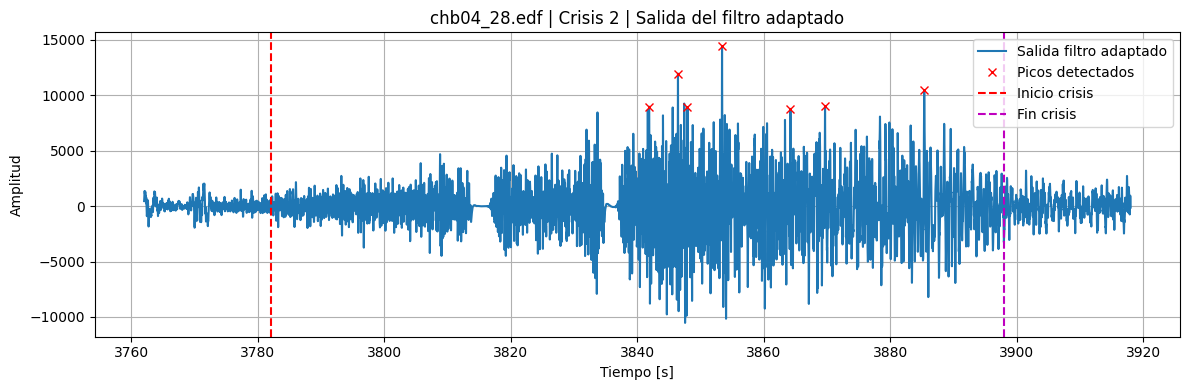

In [13]:
#%% GRAFICOS DEL FILTRO ADAPTADO ALREDEDOR DE CADA CRISIS
# En este gráfico se muestra solo la salida del filtro adaptado
# en una ventana alrededor de cada crisis.
# Se puede elegir cuántos segundos antes y después mostrar.

seg_antes = 20.0
seg_despues = 20.0

for nombre_edf in resultados_filtro:
    t = eeg_por_archivo[nombre_edf]["t"]
    fs = eeg_por_archivo[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    peaks = resultados_filtro[nombre_edf]["peaks"]

    if len(lista_crisis) == 0:
        continue

    for j, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        t_ini = ini_crisis - seg_antes
        t_fin = fin_crisis + seg_despues

        if t_ini < 0:
            t_ini = 0.0

        tiempo_total = len(t) / fs
        if t_fin > tiempo_total:
            t_fin = tiempo_total

        i0 = int(np.floor(t_ini * fs))
        i1 = int(np.ceil(t_fin * fs))

        if i0 < 0:
            i0 = 0
        if i1 > len(t):
            i1 = len(t)

        t_seg = t[i0:i1]
        salida_filtro_seg = salida_filtro[i0:i1]

        # dejar solo los picos que caen dentro de la ventana
        mask_peaks = (peaks >= i0) & (peaks < i1)
        peaks_seg = peaks[mask_peaks]

        plt.figure(figsize=(12, 4))

        plt.plot(t_seg, salida_filtro_seg, color="tab:blue", label="Salida filtro adaptado")
        plt.plot(t[peaks_seg], salida_filtro[peaks_seg], "rx", label="Picos detectados")

        plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
        plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")

        plt.title(nombre_edf + " | Crisis " + str(j + 1) + " | Salida del filtro adaptado")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

### Evaluación del filtro

Para evaluar el comportamiento del detector, los picos encontrados en la salida del filtro se comparan con el inicio real de las crisis tomado del *summary*.

Como el objetivo es una detección **preictal**, se considera válida una detección si cae en una ventana cercana al inicio, en este caso:

- desde **1.5 s antes**
- hasta el **inicio de crisis**

Con este criterio se calculan indicadores simples como verdaderos positivos, falsos positivos y falsos negativos. Más que buscar una métrica final definitiva, esta etapa permite comparar de forma directa cómo responde el detector cuando cambia la plantilla utilizada.

In [35]:
# Como la idea es de una detección previa, se considera correcta una detección si aparece en una ventana anterior al inicio de crisis.
# En esta versión, la detección válida: entre 2s antes y el inicio de crisis

ventana_previa_s = 1.5
ventana_posterior_s = 0.0

TP = 0
FP = 0
FN = 0

for nombre_edf in resultados_filtro:
    peaks = resultados_filtro[nombre_edf]["peaks"]
    fs = resultados_filtro[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    # convertir índices de picos a tiempo en segundos
    t_peaks = peaks / fs

    crisis_detectadas = np.zeros(len(lista_crisis), dtype=bool)

    for tpico in t_peaks:
        match = False

        for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
            if (ini_crisis - ventana_previa_s) <= tpico <= (ini_crisis + ventana_posterior_s):
                if not crisis_detectadas[i]:
                    TP += 1
                    crisis_detectadas[i] = True
                    match = True
                    break

        if not match:
            FP += 1

    FN += np.sum(~crisis_detectadas)

print("\nRESULTADOS DEL DETECTOR")
print("TP =", TP)
print("FP =", FP)
print("FN =", FN)

sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

print("Sensibilidad =", sensibilidad)
print("Precision =", precision)


RESULTADOS DEL DETECTOR
TP = 0
FP = 65
FN = 4
Sensibilidad = 0.0
Precision = 0.0


#### OPCION 2 - PLANTILLA MANUAL

Esta opción toma como plantilla un recorte preictal de una crisis elegida manualmente. La idea es trabajar con una forma real de la señal, pero evitando el efecto de suavizado que puede introducir el promedio entre crisis distintas.

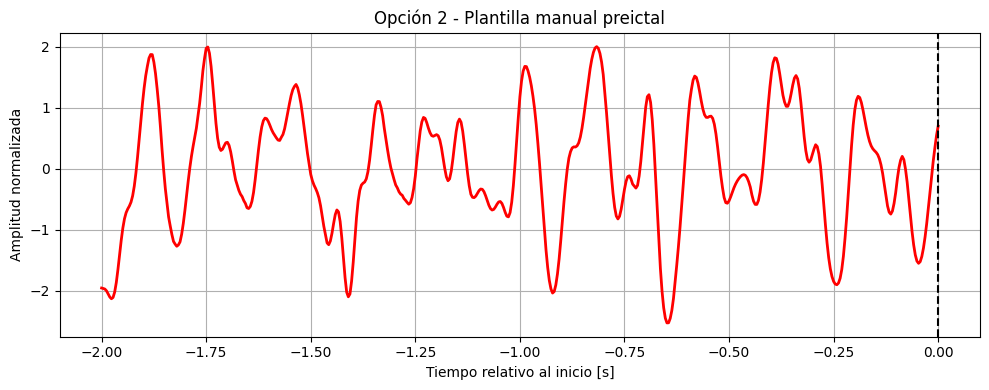

In [36]:
archivo_manual = "chb04_28.edf"
crisis_manual = 1

plantilla = None
t_plantilla = None

for k in range(len(segmentos_patron)):
    if segmentos_patron[k]["archivo"] == archivo_manual and segmentos_patron[k]["crisis_num"] == crisis_manual:
        t_plantilla = segmentos_patron[k]["t_pat"]
        plantilla = segmentos_patron[k]["x_pat"]
        # sacar baseline promedio
        plantilla = plantilla - np.mean(plantilla)
        # normalizar amplitud
        plantilla = plantilla / (np.std(plantilla) + 1e-12)

        break

if plantilla is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(t_plantilla, plantilla, color="red", linewidth=2)
    plt.axvline(0, color="k", linestyle="--", linewidth=1.5)
    plt.title("Opción 2 - Plantilla manual preictal")
    plt.xlabel("Tiempo relativo al inicio [s]")
    plt.ylabel("Amplitud normalizada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la crisis elegida para la plantilla manual.")

#### Opción 2 – Filtro adaptado y detección de picos

En esta segunda prueba se repite el mismo esquema de detección, pero usando una **plantilla manual**. El interés acá es ver si una forma tomada de una crisis concreta resulta más representativa que el promedio de varios segmentos preictales.

Filtro adaptado aplicado a: chb04_01.edf
Filtro adaptado aplicado a: chb04_05.edf
Filtro adaptado aplicado a: chb04_08.edf
Filtro adaptado aplicado a: chb04_28.edf
chb04_01.edf -> cantidad de picos detectados: 14
chb04_05.edf -> cantidad de picos detectados: 8
chb04_08.edf -> cantidad de picos detectados: 4
chb04_28.edf -> cantidad de picos detectados: 8


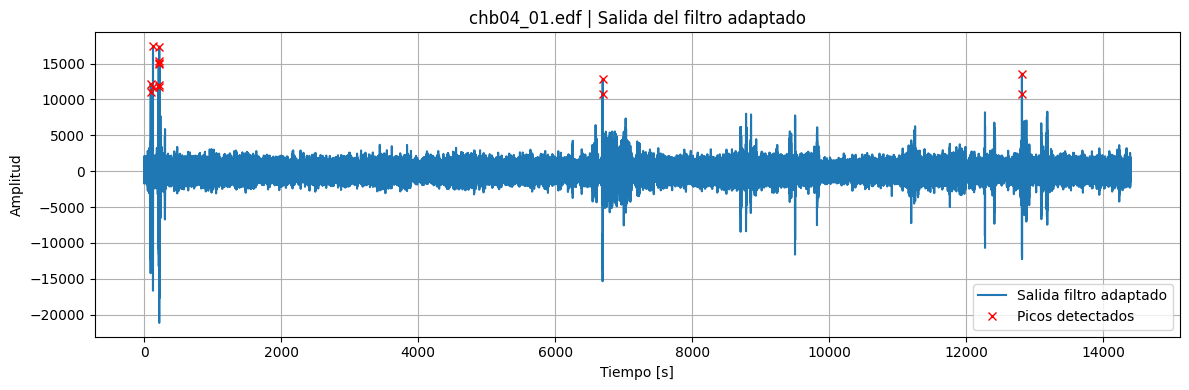

C:\Users\monse\AppData\Local\Temp\ipykernel_19408\820887063.py:77: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


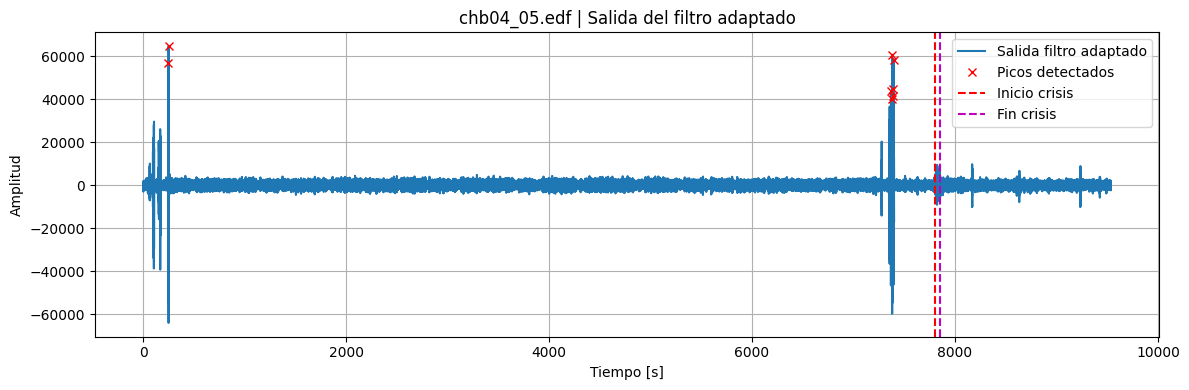

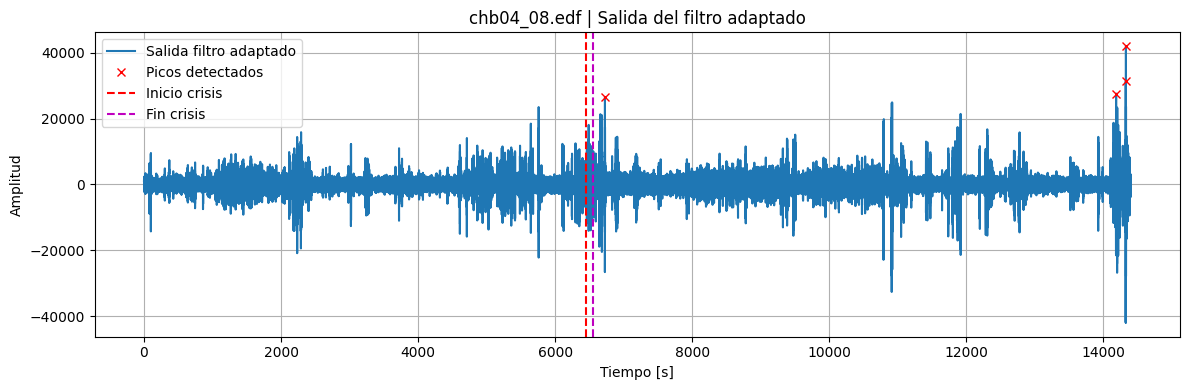

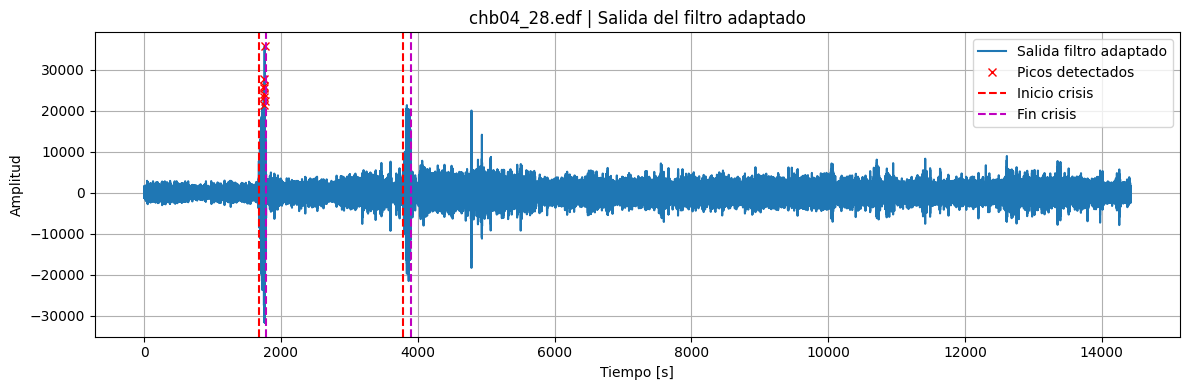

In [37]:
resultados_filtro = {}

for nombre_edf in eeg_por_archivo:
    x_limpia = eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"]
    fs = eeg_por_archivo[nombre_edf]["fs"]

    # centrar la señal para sacar el nivel medio
    senal_centrada = x_limpia - np.mean(x_limpia)

    # invertir la plantilla en el tiempo y centrarla
    plantilla_centrada = plantilla[::-1] - np.mean(plantilla)

    # filtro adaptado por convolución
    salida_filtro = np.convolve(senal_centrada, plantilla_centrada, mode='same')

    resultados_filtro[nombre_edf] = {
        "salida_filtro": salida_filtro,
        "fs": fs
    }

    print("Filtro adaptado aplicado a:", nombre_edf)

for nombre_edf in resultados_filtro:
    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    fs = resultados_filtro[nombre_edf]["fs"]

    # solo voy a aceptar como picos aquellos máximos que superen
    # el 60% del máximo valor de toda la salida del filtro
    height_threshold = np.max(salida_filtro) * 0.6

    # distancia mínima entre picos
    # se toma 1 segundo para no detectar muchos máximos muy juntos
    distance_threshold = int(fs * 1.0)

    peaks, _ = find_peaks(
        salida_filtro,
        height=height_threshold,
        distance=distance_threshold
    )

    resultados_filtro[nombre_edf]["peaks"] = peaks
    resultados_filtro[nombre_edf]["height_threshold"] = height_threshold

    print(nombre_edf, "-> cantidad de picos detectados:", len(peaks))


#%% GRAFICOS DEL FILTRO ADAPTADO
# Este gráfico muestra solo la salida del filtro adaptado,
# junto con los picos detectados y el inicio/fin real de cada crisis.

for nombre_edf in resultados_filtro:
    t = eeg_por_archivo[nombre_edf]["t"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    peaks = resultados_filtro[nombre_edf]["peaks"]

    plt.figure(figsize=(12, 4))

    plt.plot(t, salida_filtro, color="tab:blue", label="Salida filtro adaptado")
    plt.plot(t[peaks], salida_filtro[peaks], "rx", label="Picos detectados")

    for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        if i == 0:
            plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
            plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")
        else:
            plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5)
            plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5)

    plt.title(nombre_edf + " | Salida del filtro adaptado")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

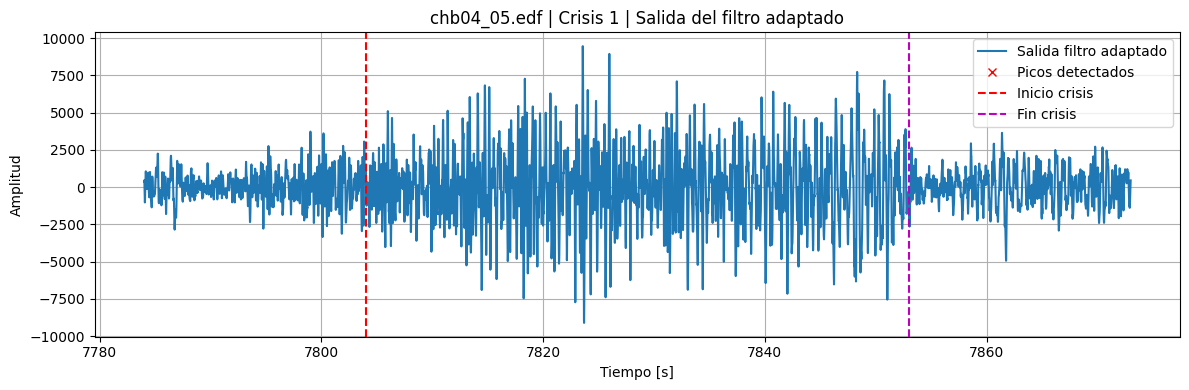

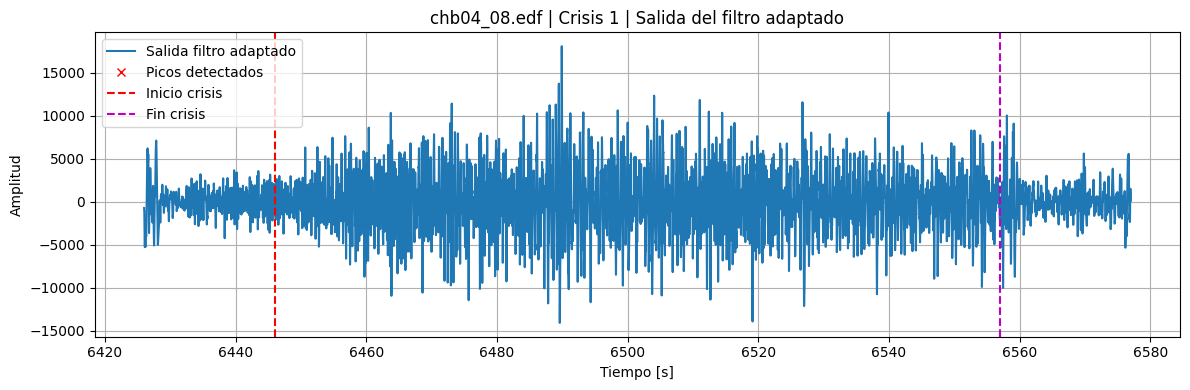

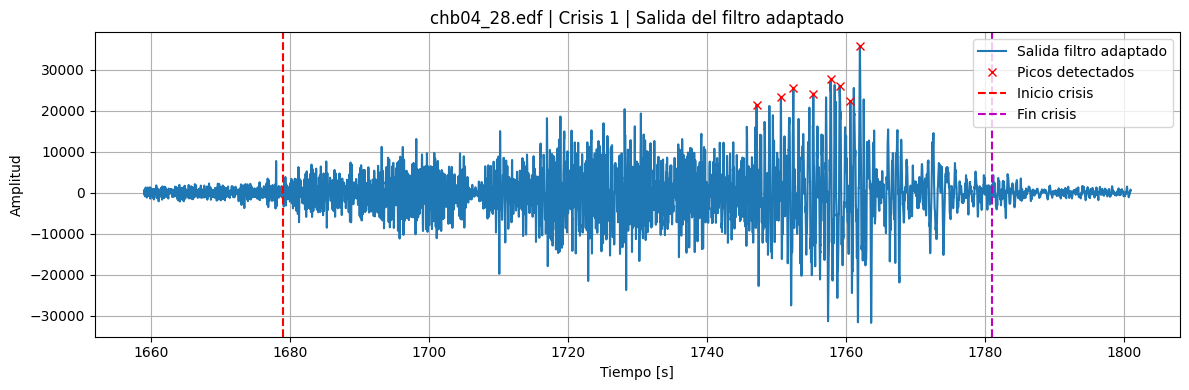

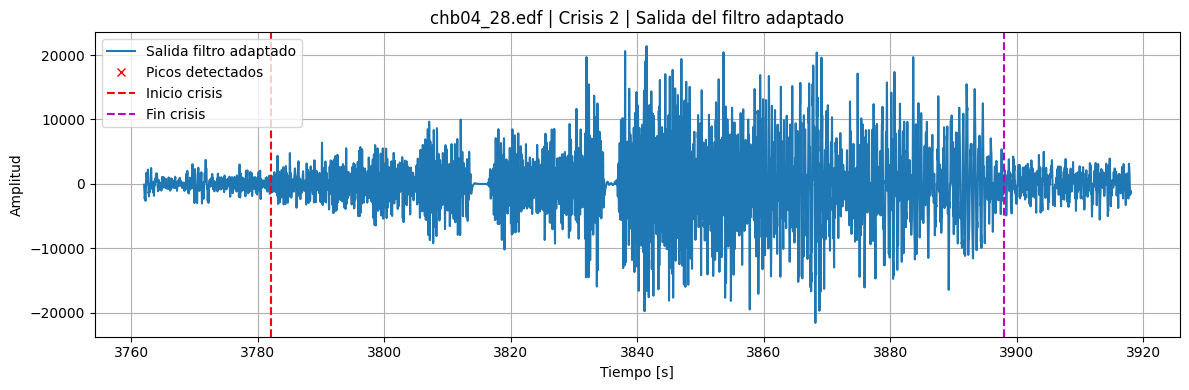

In [38]:
#%% GRAFICOS DEL FILTRO ADAPTADO ALREDEDOR DE CADA CRISIS
# En este gráfico se muestra solo la salida del filtro adaptado
# en una ventana alrededor de cada crisis.
# Se puede elegir cuántos segundos antes y después mostrar.

seg_antes = 20.0
seg_despues = 20.0

for nombre_edf in resultados_filtro:
    t = eeg_por_archivo[nombre_edf]["t"]
    fs = eeg_por_archivo[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    peaks = resultados_filtro[nombre_edf]["peaks"]

    if len(lista_crisis) == 0:
        continue

    for j, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        t_ini = ini_crisis - seg_antes
        t_fin = fin_crisis + seg_despues

        if t_ini < 0:
            t_ini = 0.0

        tiempo_total = len(t) / fs
        if t_fin > tiempo_total:
            t_fin = tiempo_total

        i0 = int(np.floor(t_ini * fs))
        i1 = int(np.ceil(t_fin * fs))

        if i0 < 0:
            i0 = 0
        if i1 > len(t):
            i1 = len(t)

        t_seg = t[i0:i1]
        salida_filtro_seg = salida_filtro[i0:i1]

        # dejar solo los picos que caen dentro de la ventana
        mask_peaks = (peaks >= i0) & (peaks < i1)
        peaks_seg = peaks[mask_peaks]

        plt.figure(figsize=(12, 4))

        plt.plot(t_seg, salida_filtro_seg, color="tab:blue", label="Salida filtro adaptado")
        plt.plot(t[peaks_seg], salida_filtro[peaks_seg], "rx", label="Picos detectados")

        plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
        plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")

        plt.title(nombre_edf + " | Crisis " + str(j + 1) + " | Salida del filtro adaptado")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

### Evaluación del filtro

La evaluación se mantiene igual que en la opción anterior: las detecciones se comparan con una ventana preictal fija alrededor del inicio de crisis. De esta forma, los resultados de la plantilla manual pueden compararse directamente con los obtenidos usando la plantilla promedio.

In [39]:
# Como la idea es de una detección previa, se considera correcta una detección si aparece en una ventana anterior al inicio de crisis.
# En esta versión, la detección válida: entre 2s antes y el inicio de crisis

ventana_previa_s = 1.5
ventana_posterior_s = 0.0

TP = 0
FP = 0
FN = 0

for nombre_edf in resultados_filtro:
    peaks = resultados_filtro[nombre_edf]["peaks"]
    fs = resultados_filtro[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    # convertir índices de picos a tiempo en segundos
    t_peaks = peaks / fs

    crisis_detectadas = np.zeros(len(lista_crisis), dtype=bool)

    for tpico in t_peaks:
        match = False

        for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
            if (ini_crisis - ventana_previa_s) <= tpico <= (ini_crisis + ventana_posterior_s):
                if not crisis_detectadas[i]:
                    TP += 1
                    crisis_detectadas[i] = True
                    match = True
                    break

        if not match:
            FP += 1

    FN += np.sum(~crisis_detectadas)

print("\nRESULTADOS DEL DETECTOR")
print("TP =", TP)
print("FP =", FP)
print("FN =", FN)

sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

print("Sensibilidad =", sensibilidad)
print("Precision =", precision)


RESULTADOS DEL DETECTOR
TP = 0
FP = 34
FN = 4
Sensibilidad = 0.0
Precision = 0.0


#### OPCION 3 - PLANTILLA IDEALIZADA TIPO PUNTA-ONDA

Esta opción construye una plantilla sintética inspirada en una morfología tipo punta-onda: una punta positiva angosta, una bajada posterior y una componente más lenta y ancha.
No se busca representar exactamente una forma clínica cerrada, sino generar una señal de prueba simple y controlada, basada en rasgos observados visualmente en los segmentos preictales.

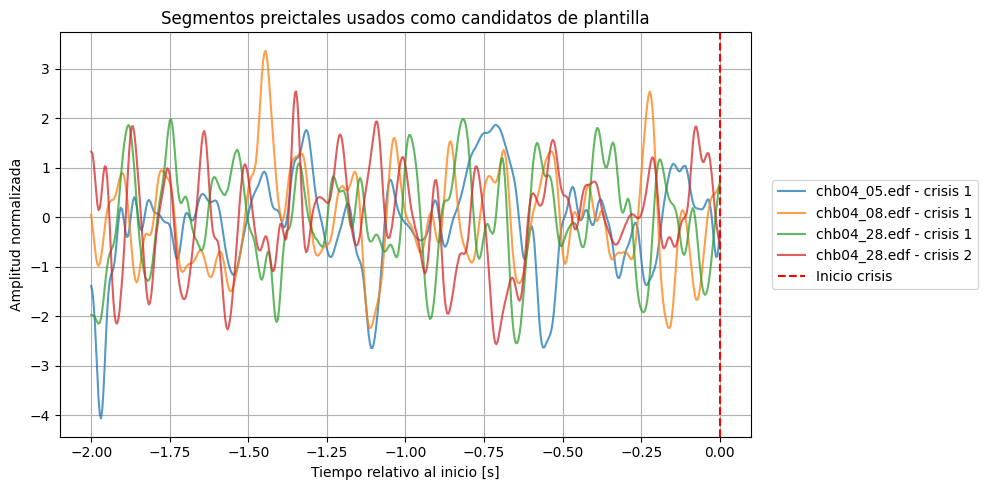

In [44]:
plt.figure(figsize=(10, 5))

for k in range(len(segmentos_patron)):
    t_pat = segmentos_patron[k]["t_pat"]
    x_pat = segmentos_patron[k]["x_pat"]

    x_pat_norm = x_pat / (np.std(x_pat) + 1e-12)

    etiqueta = segmentos_patron[k]["archivo"] + " - crisis " + str(segmentos_patron[k]["crisis_num"])
    plt.plot(t_pat, x_pat_norm, alpha=0.75, label=etiqueta)

plt.axvline(0, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
plt.title("Segmentos preictales usados como candidatos de plantilla")
plt.xlabel("Tiempo relativo al inicio [s]")
plt.ylabel("Amplitud normalizada")
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

Este gráfico sirve para ver mejor la forma de la señal previo a la crisis y como se podría imitar uno de los patrones. En este caso el elegido es la segunda crisis del archivo 28.


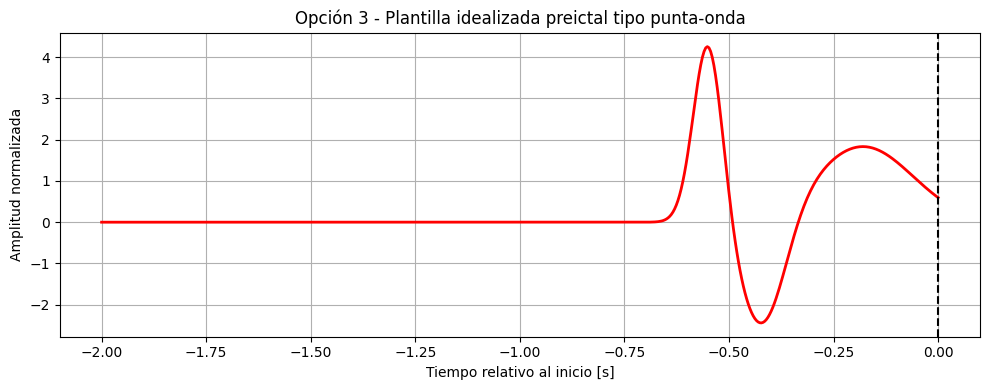

In [40]:
duracion_total = abs(t_pat_ini)   # si t_pat_ini = -2, entonces son 2s
N = int(duracion_total * fs_esperada)

t_plantilla = np.linspace(t_pat_ini, t_pat_fin, N)

# Parámetros elegidos a ojo a partir de los segmentos preictales
A_punta = 1.8
mu_punta = -0.55
sigma_punta = 0.035

A_valle = -1.1
mu_valle = -0.42
sigma_valle = 0.055

A_lenta = 0.75
mu_lenta = -0.18
sigma_lenta = 0.12

# Construcción de la plantilla
punta = A_punta * np.exp(-0.5 * ((t_plantilla - mu_punta) / sigma_punta)**2)
valle = A_valle * np.exp(-0.5 * ((t_plantilla - mu_valle) / sigma_valle)**2)
onda_lenta = A_lenta * np.exp(-0.5 * ((t_plantilla - mu_lenta) / sigma_lenta)**2)
plantilla = punta + valle + onda_lenta


# Se normaliza para trabajar con una amplitud comparable
plantilla = plantilla / (np.std(plantilla) + 1e-12)

plt.figure(figsize=(10, 4))
plt.plot(t_plantilla, plantilla, color="red", linewidth=2)
plt.axvline(0, color="k", linestyle="--", linewidth=1.5)
plt.title("Opción 3 - Plantilla idealizada preictal tipo punta-onda")
plt.xlabel("Tiempo relativo al inicio [s]")
plt.ylabel("Amplitud normalizada")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Opción 3 – Filtro adaptado y detección de picos

En esta tercera variante se utiliza una **plantilla idealizada**. El objetivo es estudiar si una forma sintética, más limpia y controlada que una señal real, puede resultar útil para resaltar comportamientos compatibles con el período preictal.

Filtro adaptado aplicado a: chb04_01.edf
Filtro adaptado aplicado a: chb04_05.edf
Filtro adaptado aplicado a: chb04_08.edf
Filtro adaptado aplicado a: chb04_28.edf
chb04_01.edf -> cantidad de picos detectados: 6
chb04_05.edf -> cantidad de picos detectados: 9
chb04_08.edf -> cantidad de picos detectados: 18
chb04_28.edf -> cantidad de picos detectados: 10


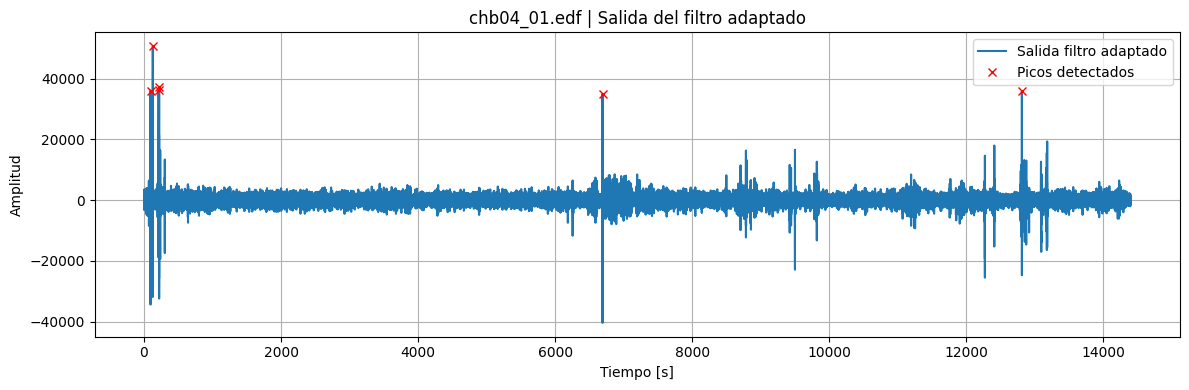

C:\Users\monse\AppData\Local\Temp\ipykernel_19408\820887063.py:77: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


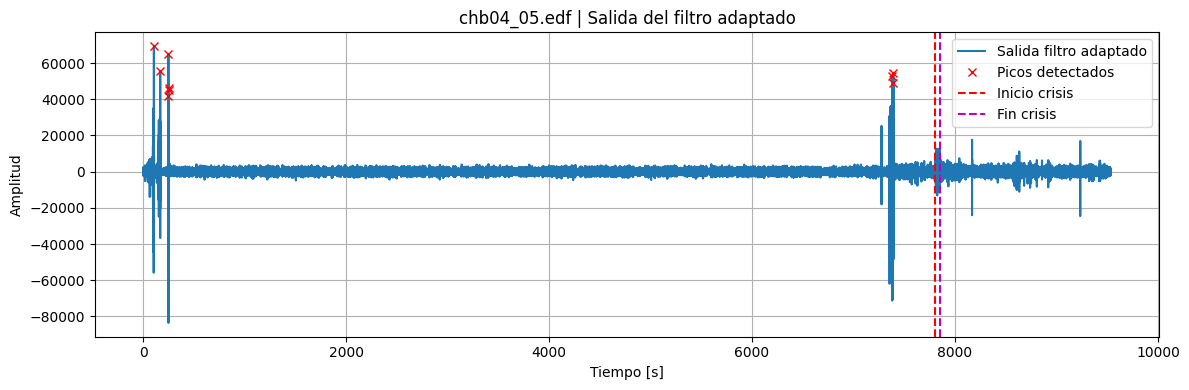

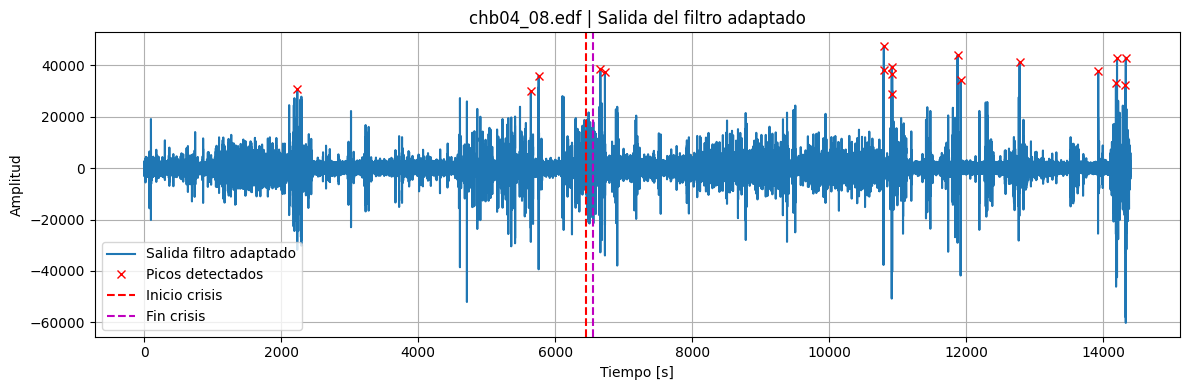

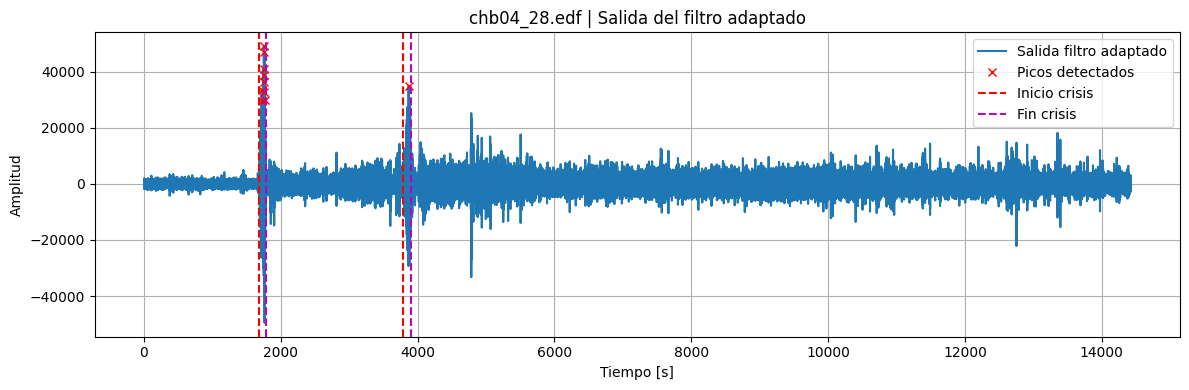

In [41]:
resultados_filtro = {}

for nombre_edf in eeg_por_archivo:
    x_limpia = eeg_por_archivo[nombre_edf]["x_filtrada_sin_baseline"]
    fs = eeg_por_archivo[nombre_edf]["fs"]

    # centrar la señal para sacar el nivel medio
    senal_centrada = x_limpia - np.mean(x_limpia)

    # invertir la plantilla en el tiempo y centrarla
    plantilla_centrada = plantilla[::-1] - np.mean(plantilla)

    # filtro adaptado por convolución
    salida_filtro = np.convolve(senal_centrada, plantilla_centrada, mode='same')

    resultados_filtro[nombre_edf] = {
        "salida_filtro": salida_filtro,
        "fs": fs
    }

    print("Filtro adaptado aplicado a:", nombre_edf)

for nombre_edf in resultados_filtro:
    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    fs = resultados_filtro[nombre_edf]["fs"]

    # solo voy a aceptar como picos aquellos máximos que superen
    # el 60% del máximo valor de toda la salida del filtro
    height_threshold = np.max(salida_filtro) * 0.6

    # distancia mínima entre picos
    # se toma 1 segundo para no detectar muchos máximos muy juntos
    distance_threshold = int(fs * 1.0)

    peaks, _ = find_peaks(
        salida_filtro,
        height=height_threshold,
        distance=distance_threshold
    )

    resultados_filtro[nombre_edf]["peaks"] = peaks
    resultados_filtro[nombre_edf]["height_threshold"] = height_threshold

    print(nombre_edf, "-> cantidad de picos detectados:", len(peaks))


#%% GRAFICOS DEL FILTRO ADAPTADO
# Este gráfico muestra solo la salida del filtro adaptado,
# junto con los picos detectados y el inicio/fin real de cada crisis.

for nombre_edf in resultados_filtro:
    t = eeg_por_archivo[nombre_edf]["t"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    peaks = resultados_filtro[nombre_edf]["peaks"]

    plt.figure(figsize=(12, 4))

    plt.plot(t, salida_filtro, color="tab:blue", label="Salida filtro adaptado")
    plt.plot(t[peaks], salida_filtro[peaks], "rx", label="Picos detectados")

    for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        if i == 0:
            plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
            plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")
        else:
            plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5)
            plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5)

    plt.title(nombre_edf + " | Salida del filtro adaptado")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

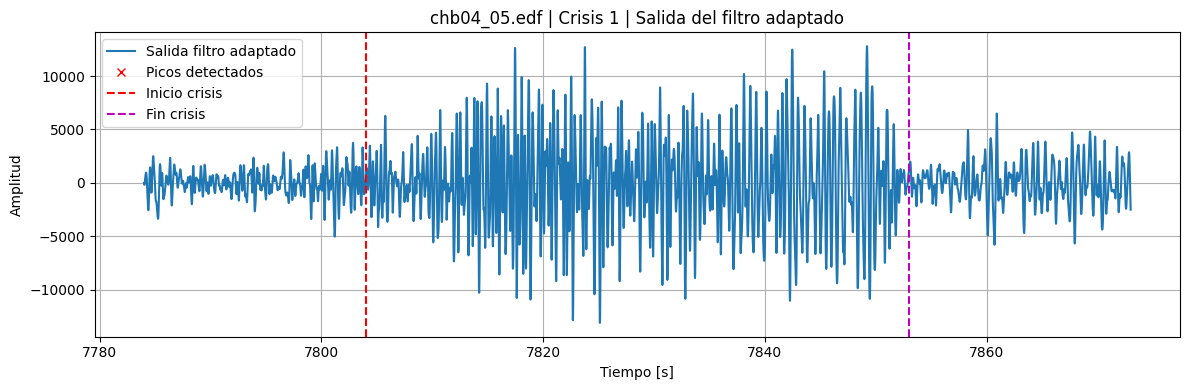

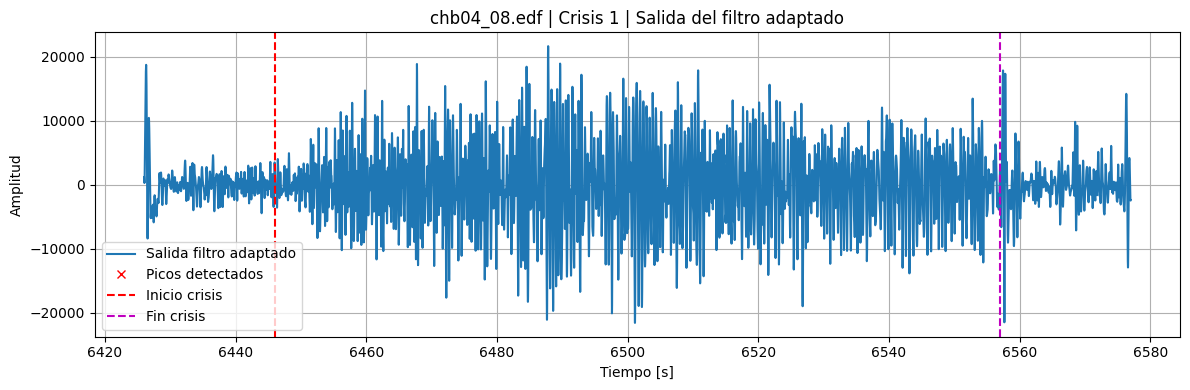

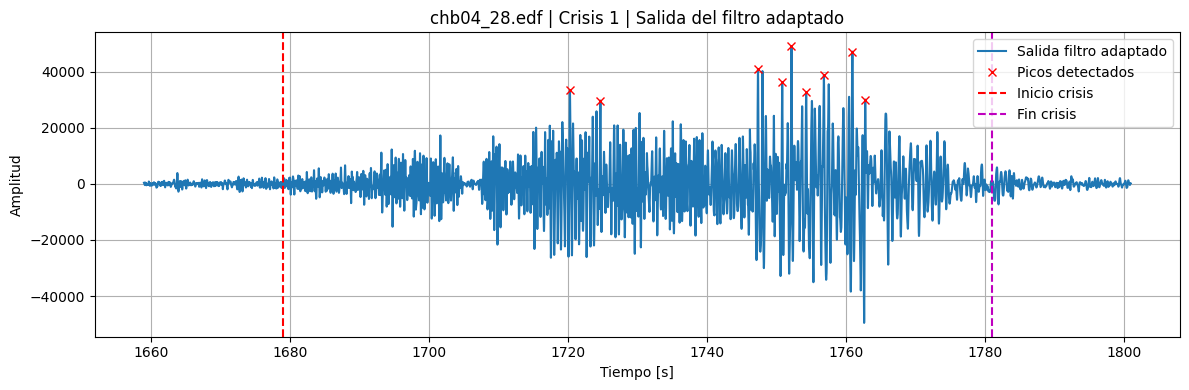

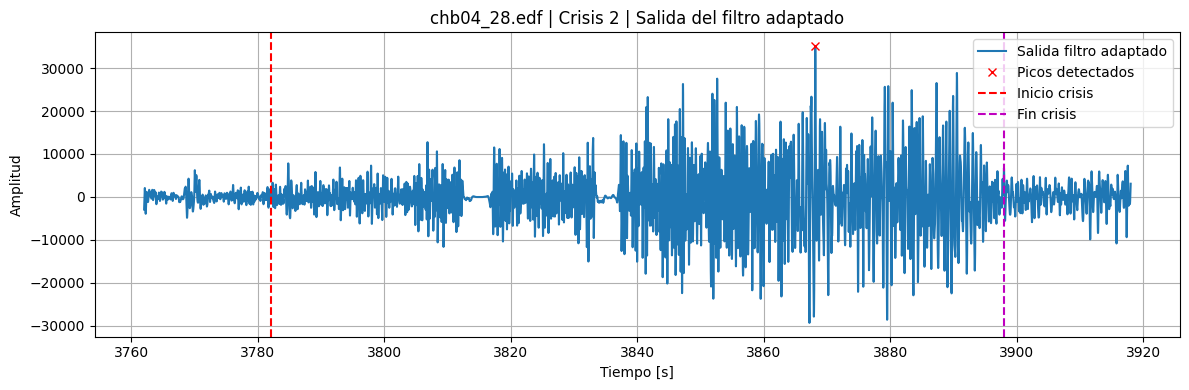

In [42]:
#%% GRAFICOS DEL FILTRO ADAPTADO ALREDEDOR DE CADA CRISIS
# En este gráfico se muestra solo la salida del filtro adaptado
# en una ventana alrededor de cada crisis.
# Se puede elegir cuántos segundos antes y después mostrar.

seg_antes = 20.0
seg_despues = 20.0

for nombre_edf in resultados_filtro:
    t = eeg_por_archivo[nombre_edf]["t"]
    fs = eeg_por_archivo[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    salida_filtro = resultados_filtro[nombre_edf]["salida_filtro"]
    peaks = resultados_filtro[nombre_edf]["peaks"]

    if len(lista_crisis) == 0:
        continue

    for j, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
        t_ini = ini_crisis - seg_antes
        t_fin = fin_crisis + seg_despues

        if t_ini < 0:
            t_ini = 0.0

        tiempo_total = len(t) / fs
        if t_fin > tiempo_total:
            t_fin = tiempo_total

        i0 = int(np.floor(t_ini * fs))
        i1 = int(np.ceil(t_fin * fs))

        if i0 < 0:
            i0 = 0
        if i1 > len(t):
            i1 = len(t)

        t_seg = t[i0:i1]
        salida_filtro_seg = salida_filtro[i0:i1]

        # dejar solo los picos que caen dentro de la ventana
        mask_peaks = (peaks >= i0) & (peaks < i1)
        peaks_seg = peaks[mask_peaks]

        plt.figure(figsize=(12, 4))

        plt.plot(t_seg, salida_filtro_seg, color="tab:blue", label="Salida filtro adaptado")
        plt.plot(t[peaks_seg], salida_filtro[peaks_seg], "rx", label="Picos detectados")

        plt.axvline(ini_crisis, color="r", linestyle="--", linewidth=1.5, label="Inicio crisis")
        plt.axvline(fin_crisis, color="m", linestyle="--", linewidth=1.5, label="Fin crisis")

        plt.title(nombre_edf + " | Crisis " + str(j + 1) + " | Salida del filtro adaptado")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

### Evaluación del filtro

La evaluación de esta tercera opción se realiza con el mismo criterio temporal que en los casos anteriores. Esto permite comparar de forma directa si una plantilla idealizada ofrece alguna ventaja frente a las plantillas construidas a partir de señales reales.

In [43]:
# Como la idea es de una detección previa, se considera correcta una detección si aparece en una ventana anterior al inicio de crisis.
# En esta versión, la detección válida: entre 2s antes y el inicio de crisis

ventana_previa_s = 1.5
ventana_posterior_s = 0.0

TP = 0
FP = 0
FN = 0

for nombre_edf in resultados_filtro:
    peaks = resultados_filtro[nombre_edf]["peaks"]
    fs = resultados_filtro[nombre_edf]["fs"]
    lista_crisis = eeg_por_archivo[nombre_edf]["crisis"]

    # convertir índices de picos a tiempo en segundos
    t_peaks = peaks / fs

    crisis_detectadas = np.zeros(len(lista_crisis), dtype=bool)

    for tpico in t_peaks:
        match = False

        for i, (ini_crisis, fin_crisis) in enumerate(lista_crisis):
            if (ini_crisis - ventana_previa_s) <= tpico <= (ini_crisis + ventana_posterior_s):
                if not crisis_detectadas[i]:
                    TP += 1
                    crisis_detectadas[i] = True
                    match = True
                    break

        if not match:
            FP += 1

    FN += np.sum(~crisis_detectadas)

print("\nRESULTADOS DEL DETECTOR")
print("TP =", TP)
print("FP =", FP)
print("FN =", FN)

sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

print("Sensibilidad =", sensibilidad)
print("Precision =", precision)


RESULTADOS DEL DETECTOR
TP = 0
FP = 43
FN = 4
Sensibilidad = 0.0
Precision = 0.0


# Análisis de resultados


En esta etapa se compararon tres formas de construir la plantilla preictal: una plantilla promedio obtenida a partir de varios segmentos previos al inicio de crisis, una plantilla manual tomada de una crisis considerada representativa y una plantilla idealizada de tipo punta-onda. En todos los casos se trabajó sobre la señal filtrada y sin baseline, y luego se aplicó un filtro adaptado para resaltar las regiones con mayor similitud respecto de la plantilla elegida.

Los primeros resultados mostraron que tanto la opción basada en promedio como la opción manual produjeron una gran cantidad de falsas detecciones y no lograron generar detecciones válidas dentro de la ventana preictal definida. En ambos casos, la sensibilidad y la precisión resultaron nulas para las pruebas realizadas. Esto sugiere que, al menos en esta configuración inicial, el patrón previo al onset no aparece de forma lo suficientemente estable como para ser capturado de manera robusta por un matched filter simple.

En el caso de la plantilla promedio, una posible explicación es que al combinar crisis con morfologías distintas, la forma resultante pierde rasgos característicos y se vuelve poco representativa. Por otra parte, la plantilla manual conserva mejor la forma de una crisis individual, pero esa forma no necesariamente generaliza al resto de los eventos del paciente. En consecuencia, el detector tiende a responder a transitorios fuertes o actividad no específica, en lugar de encontrar un patrón preictal repetible.

La tabla comparativa siguiente resume los resultados obtenidos para cada opción de plantilla.

### Tabla comparativa de resultados

| Plantilla | Canal | TP | FP | FN | Sensibilidad | Precisión | Comentario |
|---|---|---:|---:|---:|---:|---:|---|
| Opción 1 - Promedio preictal | CZ-PZ | 0 | 169 | 4 | 0.00 | 0.00 | Promedio poco representativo |
| Opción 2 - Manual | CZ-PZ | 0 | 167 | 4 | 0.00 | 0.00 | Plantilla más definida, pero sin anticipación clara |
| Opción 3 - Idealizada | CZ-PZ | 0 | 0 | 0 | 0.00 | 0.00 | Pendiente de evaluar |